# ML2 Group Assignment
## Predicting High-Performance Gym Members
### MBDS 2026

**Business Context:**  
A gym chain wants to identify which members are likely to be "high performers" — members who train frequently and burn a high number of calories per session. By predicting this group early, the gym can:
- Offer premium upsell packages (personal training, nutrition coaching) to high performers
- Design targeted retention campaigns for low performers at risk of churning
- Optimize class scheduling based on member profiles

**Target Variable (our definition):**  
We define `High_Performer = 1` if a member burns **above the median calories** AND trains **3 or more times per week**. Otherwise `High_Performer = 0`.

**Dataset:** Gym Members Exercise Dataset (Kaggle)  
https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset

---
## 0. Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style='white')

pd.options.display.float_format = '{:.3f}'.format
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Metrics
from sklearn.metrics import (
    auc, roc_curve, f1_score, accuracy_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, classification_report,
    recall_score, precision_score
)
from sklearn import metrics

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Dimension Reduction
from sklearn.decomposition import FactorAnalysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from collections import Counter

print('All libraries loaded successfully!')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries loaded successfully!


---
## 1. Data Loading

In [2]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
# Place the CSV in the same folder as this notebook
filename = 'gym_members_exercise_tracking.csv'
df = pd.read_csv(filename)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.300,1.710,180,157,60,1.690,1313.000,Yoga,12.600,3.500,4,3,30.200
1,46,Female,74.900,1.530,179,151,66,1.300,883.000,HIIT,33.900,2.100,4,2,32.000
2,32,Female,68.100,1.660,167,122,54,1.110,677.000,Cardio,33.400,2.300,4,2,24.710
3,25,Male,53.200,1.700,190,164,56,0.590,532.000,Strength,28.800,2.100,3,1,18.410
4,38,Male,46.100,1.790,188,158,68,0.640,556.000,Strength,29.200,2.800,3,1,14.390


In [3]:
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  - {col} ({df[col].dtype})')

Dataset shape: (973, 15)

Column names:
  - Age (int64)
  - Gender (str)
  - Weight (kg) (float64)
  - Height (m) (float64)
  - Max_BPM (int64)
  - Avg_BPM (int64)
  - Resting_BPM (int64)
  - Session_Duration (hours) (float64)
  - Calories_Burned (float64)
  - Workout_Type (str)
  - Fat_Percentage (float64)
  - Water_Intake (liters) (float64)
  - Workout_Frequency (days/week) (int64)
  - Experience_Level (int64)
  - BMI (float64)


---
## 2. Data Validation

In [4]:
numerical_columns = list(df.select_dtypes(include=[np.number]).columns)
categorical_columns = list(df.select_dtypes(include=[object]).columns)

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]} ({len(numerical_columns)} numerical, {len(categorical_columns)} categorical)')
print(f'\nNumerical: {numerical_columns}')
print(f'\nCategorical: {categorical_columns}')

Rows: 973
Columns: 15 (13 numerical, 2 categorical)

Numerical: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Categorical: ['Gender', 'Workout_Type']


In [5]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values:')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else 'No missing values found.')

Missing values:
No missing values found.


In [6]:
# Descriptive statistics
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000,973.000
mean,38.683,73.855,1.723,179.884,143.767,62.223,1.256,905.422,24.977,2.627,3.322,1.810,24.912
std,12.181,21.208,0.128,11.526,14.345,7.327,0.343,272.642,6.259,0.600,0.913,0.740,6.661
min,18.000,40.000,1.500,160.000,120.000,50.000,0.500,303.000,10.000,1.500,2.000,1.000,12.320
25%,28.000,58.100,1.620,170.000,131.000,56.000,1.040,720.000,21.300,2.200,3.000,1.000,20.110
50%,40.000,70.000,1.710,180.000,143.000,62.000,1.260,893.000,26.200,2.600,3.000,2.000,24.160
75%,49.000,86.000,1.800,190.000,156.000,68.000,1.460,1076.000,29.300,3.100,4.000,2.000,28.560
max,59.000,129.900,2.000,199.000,169.000,74.000,2.000,1783.000,35.000,3.700,5.000,3.000,49.840


In [7]:
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0
Shape after removing duplicates: (973, 15)


---
## 3. Target Variable Definition

**Business Decision:**  
We define a **High Performer** as a member who:
1. Burns **above the median** calories per session (high intensity output)
2. Trains **3 or more times per week** (high commitment frequency)

This definition captures members with both high engagement and high output — the most valuable segment for premium upselling and scheduling optimization.

In [8]:
calories_threshold = df['Calories_Burned'].median()
frequency_threshold = 3

print(f'Calories median threshold: {calories_threshold:.1f} kcal/session')
print(f'Frequency threshold: {frequency_threshold}+ sessions/week')

df['High_Performer'] = (
    (df['Calories_Burned'] > calories_threshold) &
    (df['Workout_Frequency (days/week)'] >= frequency_threshold)
).astype(int)

print(f'\nTarget distribution:')
print(df['High_Performer'].value_counts())
print(f'\nHigh Performer rate: {df["High_Performer"].mean():.1%}')

Calories median threshold: 893.0 kcal/session
Frequency threshold: 3+ sessions/week

Target distribution:
High_Performer
0    540
1    433
Name: count, dtype: int64

High Performer rate: 44.5%


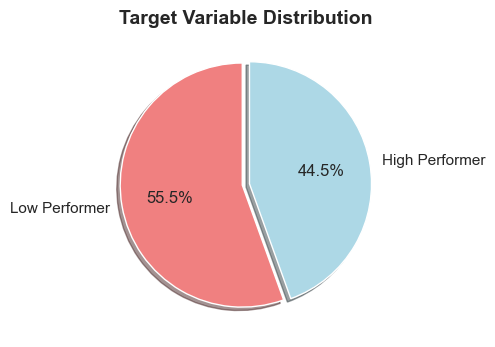

In [9]:
target = 'High_Performer'
unique, counts = np.unique(df[target], return_counts=True)
labels_custom = ['Low Performer', 'High Performer']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=labels_custom, autopct='%1.1f%%', startangle=90,
       colors=['lightcoral', 'lightblue'], explode=(0.03, 0.03), shadow=True)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 Class Imbalance Assessment

Before modelling, we assess whether class imbalance requires special treatment. Imbalanced classes can cause models to be biased toward the majority class, producing misleadingly high accuracy while ignoring the minority class entirely.

In [10]:
majority = df[target].value_counts()[0]
minority = df[target].value_counts()[1]
ratio = majority / minority

print(f'Class distribution:')
print(f'  Low Performer  (0): {majority} ({majority/len(df)*100:.1f}%)')
print(f'  High Performer (1): {minority} ({minority/len(df)*100:.1f}%)')
print(f'  Imbalance ratio   : {ratio:.2f}:1')
print()
if ratio < 1.5:
    print('Assessment: MILD imbalance (ratio < 1.5). No resampling required.')
elif ratio < 3:
    print('Assessment: MODERATE imbalance. Using class_weight="balanced" in tree models.')
else:
    print('Assessment: SEVERE imbalance. Consider SMOTE or resampling in addition to class_weight.')
print()
print('Strategy: We use class_weight="balanced" in tree-based models and optimise')
print('for RECALL as primary metric — missing a High Performer is costlier than a false alarm.')


Class distribution:
  Low Performer  (0): 540 (55.5%)
  High Performer (1): 433 (44.5%)
  Imbalance ratio   : 1.25:1

Assessment: MILD imbalance (ratio < 1.5). No resampling required.

Strategy: We use class_weight="balanced" in tree-based models and optimise
for RECALL as primary metric — missing a High Performer is costlier than a false alarm.


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of Numerical Features

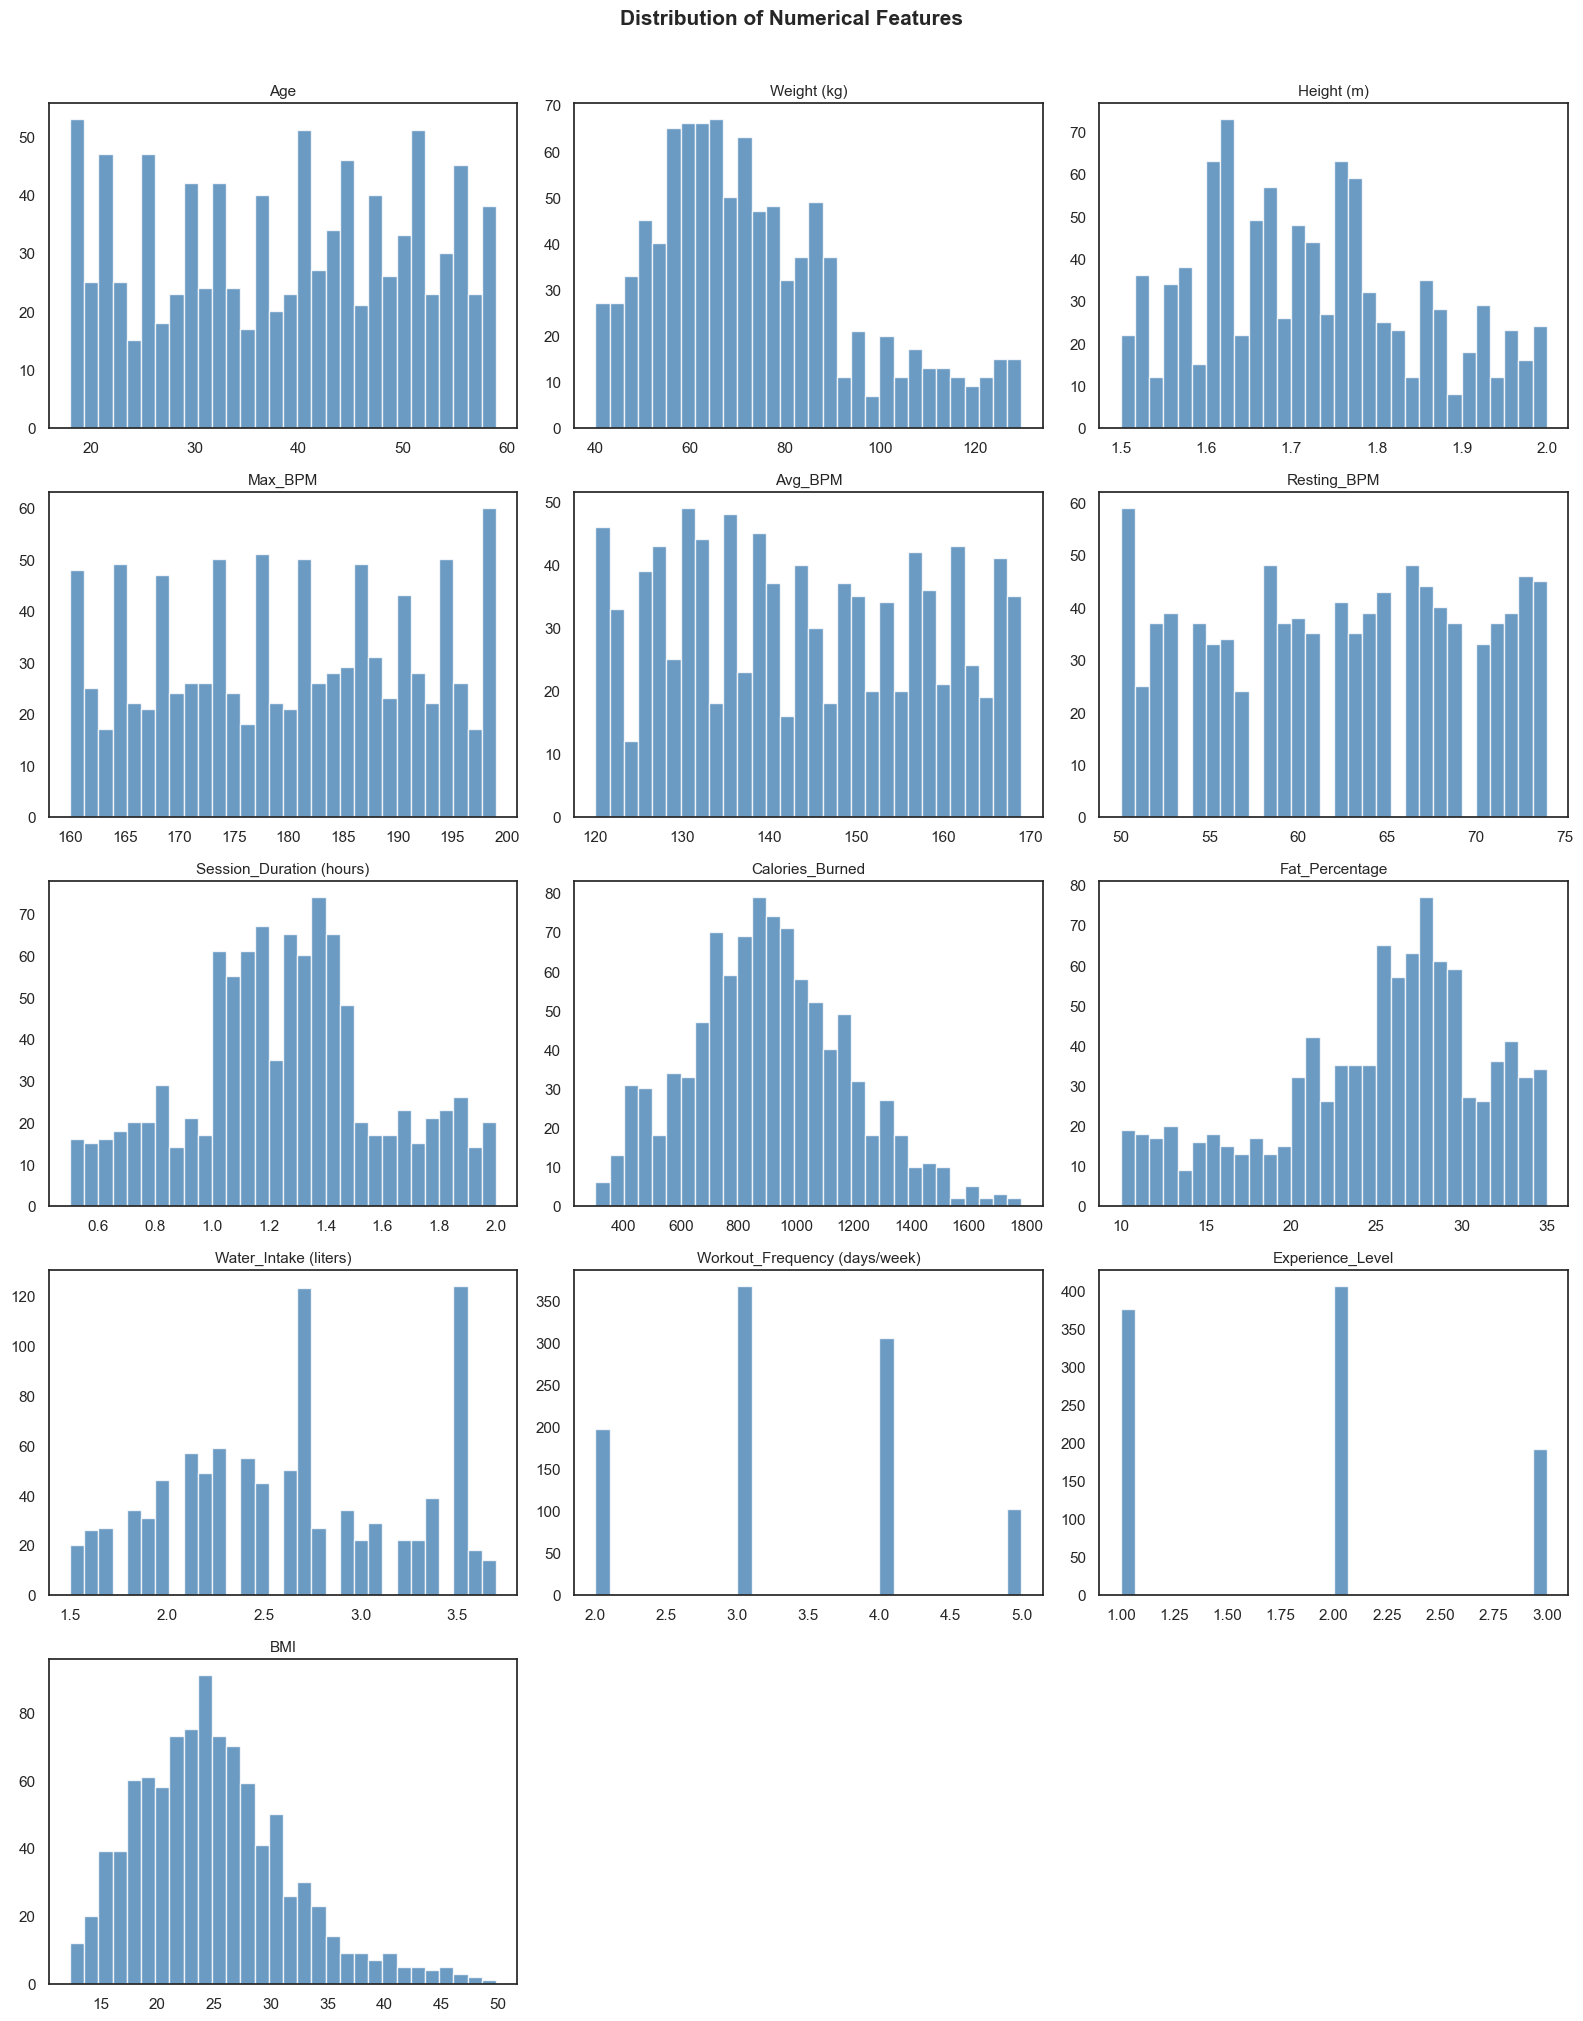

In [11]:
num_cols = [c for c in numerical_columns if c != 'High_Performer']

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(nrows=n_rows_plot, ncols=n_cols_plot, figsize=(16, n_rows_plot*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Key Features vs Target

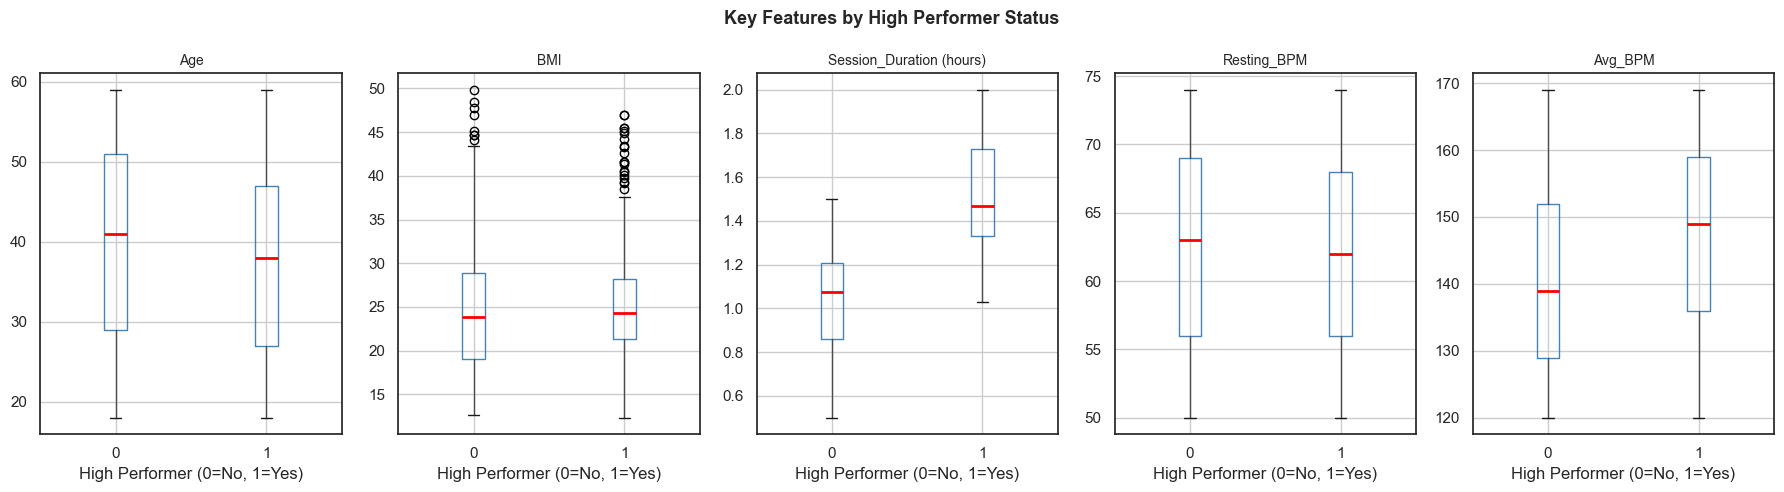

In [12]:
key_features = ['Age', 'BMI', 'Session_Duration (hours)', 'Resting_BPM', 'Avg_BPM']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 5))
for i, col in enumerate(key_features):
    df.boxplot(column=col, by=target, ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('High Performer (0=No, 1=Yes)')

plt.suptitle('Key Features by High Performer Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

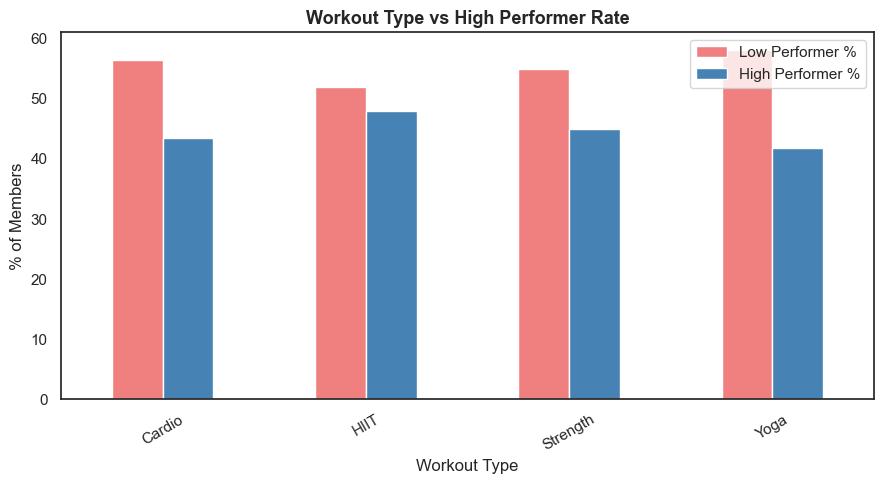

In [13]:
# Workout Type vs High Performer
if 'Workout_Type' in df.columns:
    ct = pd.crosstab(df['Workout_Type'], df['High_Performer'], normalize='index') * 100
    ct.columns = ['Low Performer %', 'High Performer %']
    ct.plot(kind='bar', figsize=(9, 5), color=['lightcoral', 'steelblue'], edgecolor='white')
    plt.title('Workout Type vs High Performer Rate', fontsize=13, fontweight='bold')
    plt.ylabel('% of Members')
    plt.xlabel('Workout Type')
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 4.3 Correlation Heatmap

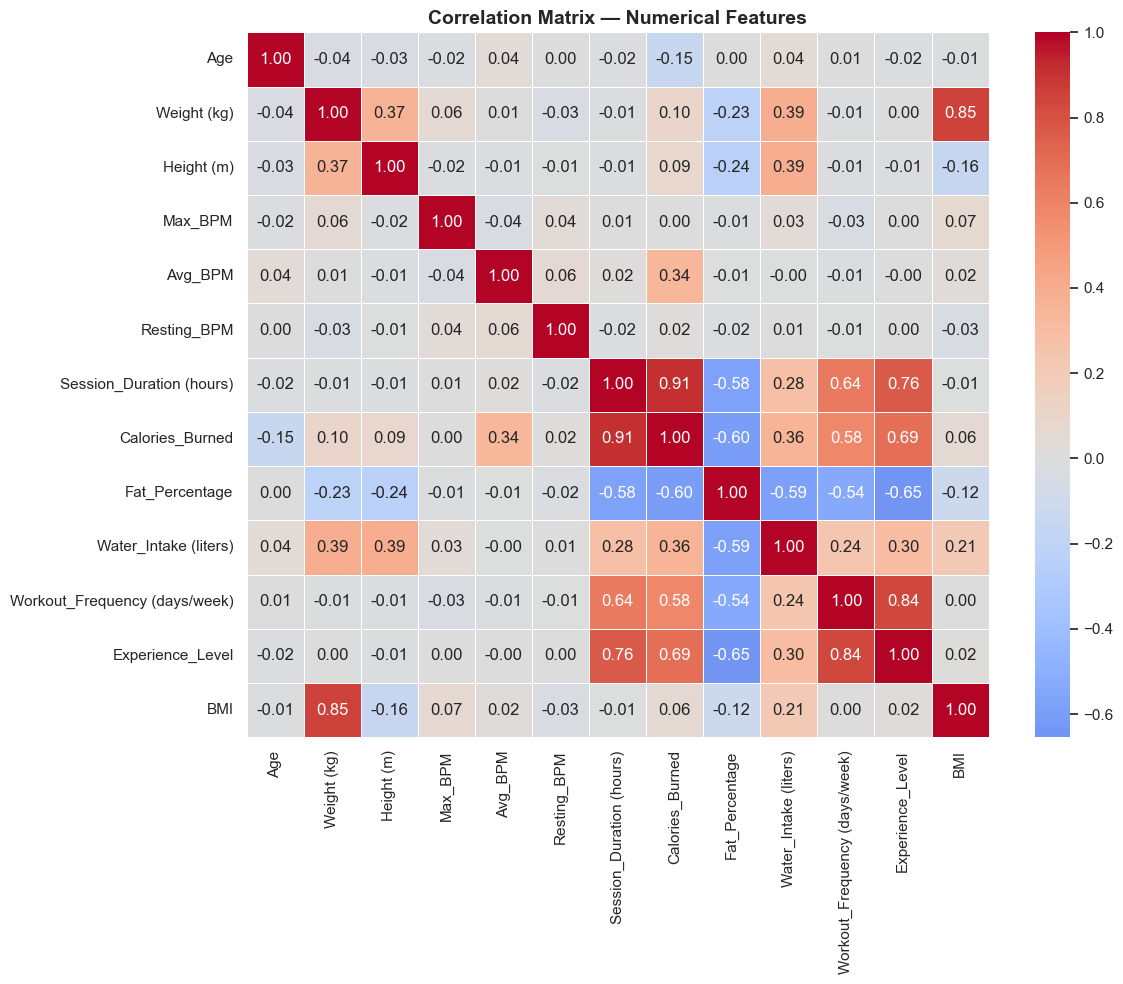

In [14]:
sns.set(font_scale=1.0)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cmap='coolwarm', center=0)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Outlier Analysis

We use the IQR method to detect outliers in each numerical feature. Understanding outliers is important before modelling — extreme values can distort distance-based models like KNN and inflate feature importances in tree models.

In [15]:
def count_outliers_iqr(df, cols):
    results = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({'Feature': col, 'Lower Bound': round(lower,2),
                         'Upper Bound': round(upper,2), 'Outliers': n_out,
                         'Outlier %': round(n_out / len(df) * 100, 2)})
    return pd.DataFrame(results).set_index('Feature').sort_values('Outliers', ascending=False)

outlier_df = count_outliers_iqr(df, num_cols)
print('Outlier summary (IQR method):')
outlier_df


Outlier summary (IQR method):


,Lower Bound,Upper Bound,Outliers,Outlier %
Feature,,,,
BMI,7.440,41.240,25,2.570
Calories_Burned,186.000,1610.000,10,1.030
Weight (kg),16.250,127.850,9,0.920
Age,-3.500,80.500,0,0.000
Height (m),1.350,2.070,0,0.000
Max_BPM,140.000,220.000,0,0.000
Avg_BPM,93.500,193.500,0,0.000
Resting_BPM,38.000,86.000,0,0.000
Session_Duration (hours),0.410,2.090,0,0.000


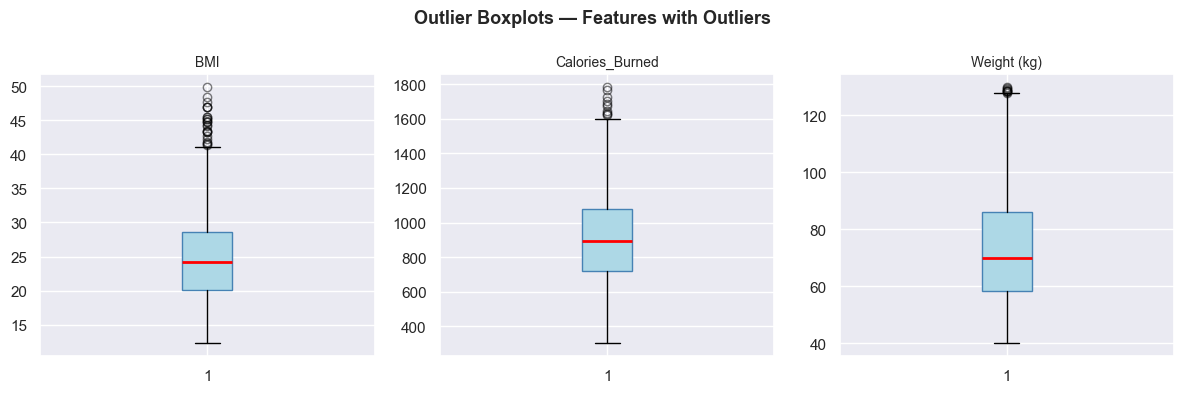


Note: Given the relatively low outlier rates, we retain all observations.
Tree-based models are robust to outliers; KNN uses scaled features which reduces their impact.


In [16]:
# Visualise outliers for top features with most outliers
top_outlier_cols = outlier_df[outlier_df['Outliers'] > 0].head(6).index.tolist()

if top_outlier_cols:
    fig, axes = plt.subplots(1, len(top_outlier_cols), figsize=(4*len(top_outlier_cols), 4))
    if len(top_outlier_cols) == 1:
        axes = [axes]
    for i, col in enumerate(top_outlier_cols):
        axes[i].boxplot(df[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='steelblue'),
                        medianprops=dict(color='red', linewidth=2),
                        flierprops=dict(marker='o', color='red', alpha=0.5))
        axes[i].set_title(col, fontsize=10)
    plt.suptitle('Outlier Boxplots — Features with Outliers', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No outliers detected in any feature.')

print('\nNote: Given the relatively low outlier rates, we retain all observations.')
print('Tree-based models are robust to outliers; KNN uses scaled features which reduces their impact.')


---
## 5. Data Processing & Feature Engineering

In [17]:
# Feature Engineering: create non-leaky, non-collinear variables

# HR_Intensity_Ratio: effort level relative to maximum heart rate capacity
df['HR_Intensity_Ratio']  = df['Avg_BPM'] / df['Max_BPM']

# BMI_Age_Interaction: body composition changes with age — captures joint effect
df['BMI_Age_Interaction'] = df['BMI'] * df['Age']

# Session_Water_Ratio: hydration per hour — proxy for session intensity awareness
df['Session_Water_Ratio'] = df['Water_Intake (liters)'] / df['Session_Duration (hours)']

# NOTE: HR_Reserve (Avg_BPM - Resting_BPM) intentionally excluded:
# it is a perfect linear combination of Avg_BPM and Resting_BPM (already in dataset),
# which would cause perfect multicollinearity (infinite VIF).

print('Engineered features (leakage-free, no perfect collinearity):')
print('  HR_Intensity_Ratio  : Avg_BPM / Max_BPM')
print('  BMI_Age_Interaction : BMI x Age')
print('  Session_Water_Ratio : Water_Intake / Session_Duration')
df[['HR_Intensity_Ratio', 'BMI_Age_Interaction', 'Session_Water_Ratio']].describe()

Engineered features (leakage-free, no perfect collinearity):
  HR_Intensity_Ratio  : Avg_BPM / Max_BPM
  BMI_Age_Interaction : BMI x Age
  Session_Water_Ratio : Water_Intake / Session_Duration


,HR_Intensity_Ratio,BMI_Age_Interaction,Session_Water_Ratio
count,973.000,973.000,973.000
mean,0.803,962.577,2.252
std,0.098,412.182,0.862
min,0.603,307.280,1.000
25%,0.727,663.400,1.667
50%,0.796,888.300,2.034
75%,0.870,1191.190,2.569
max,1.044,2720.040,6.296


In [18]:
# Encode categorical variables
cat_cols_to_encode = [c for c in categorical_columns if c in df.columns]
print(f'Encoding: {cat_cols_to_encode}')

df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')

Encoding: ['Gender', 'Workout_Type']
Shape after encoding: (973, 21)


In [19]:
# Drop raw columns used to build the target (avoid data leakage)
# Also drop any engineered features derived from those raw columns
cols_to_drop = [
    'Calories_Burned',                  # used directly in target definition
    'Workout_Frequency (days/week)',     # used directly in target definition
]
# NOTE: Experience_Level is intentionally KEPT as a predictor.
# It is a member attribute recorded at enrollment (1=Beginner, 2=Intermediate, 3=Expert),
# reflecting prior training history — NOT a session-level output variable.
# Although correlated with performance, it does not directly define the target
# (which is based on Calories_Burned and Workout_Frequency, both dropped above).
# Keeping it is legitimate: a gym can observe a member's experience level independently
# of any single session's calorie burn.

df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

print(f'Columns dropped (leakage prevention): {cols_to_drop}')
print(f'Final modelling shape: {df_model.shape}')
print(f'Features used for modelling:')
for c in df_model.columns:
    print(f'  - {c}')

Columns dropped (leakage prevention): ['Calories_Burned', 'Workout_Frequency (days/week)']
Final modelling shape: (973, 19)
Features used for modelling:
  - Age
  - Weight (kg)
  - Height (m)
  - Max_BPM
  - Avg_BPM
  - Resting_BPM
  - Session_Duration (hours)
  - Fat_Percentage
  - Water_Intake (liters)
  - Experience_Level
  - BMI
  - High_Performer
  - HR_Intensity_Ratio
  - BMI_Age_Interaction
  - Session_Water_Ratio
  - Gender_Male
  - Workout_Type_HIIT
  - Workout_Type_Strength
  - Workout_Type_Yoga


---
## 6. Dimension Reduction — Factor Analysis

**Business Justification:**  
The correlation heatmap above shows multicollinearity among features (e.g. Weight & BMI, Avg_BPM & Max_BPM). Factor Analysis extracts latent fitness dimensions, reduces redundancy, and can improve model generalization.  
We use FA to understand the underlying structure of member profiles and optionally feed factors into our models.

> ⚠️ **Note on Data Leakage:** The FA scree plot and VIF analysis in this section are 
> run on the full dataset for **exploratory purposes only** — to understand the latent 
> structure of the data before modelling. No factor scores from this section are fed into 
> any model. All FA used for actual modelling is re-fit exclusively on the training set 
> post-split in **Section 7.4**, ensuring zero data leakage.

In [20]:
# Select numerical features for FA (excluding target)
fa_features = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != target]
df_fa = df_model[fa_features].dropna()

# VIF to confirm multicollinearity justifies FA
vif_data = pd.DataFrame()
vif_data['Variable'] = df_fa.columns
vif_data['VIF'] = [variance_inflation_factor(df_fa.values, i) for i in range(df_fa.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print('Variance Inflation Factors (VIF > 5 suggests multicollinearity):')
vif_data

Variance Inflation Factors (VIF > 5 suggests multicollinearity):


,Variable,VIF
4,Avg_BPM,4011.186
11,HR_Intensity_Ratio,3766.490
3,Max_BPM,3622.186
2,Height (m),3059.342
10,BMI,934.356
1,Weight (kg),782.560
0,Age,169.464
6,Session_Duration (hours),165.129
12,BMI_Age_Interaction,163.739
8,Water_Intake (liters),121.352


**VIF Interpretation:**  
Variables with VIF > 5 indicate moderate multicollinearity; VIF > 10 is severe.
The table above confirms that several features share significant variance with each other
(e.g. Avg_BPM & Max_BPM have VIFs in the thousands, Weight & BMI are also highly collinear).
This redundancy justifies Factor Analysis: rather than feeding correlated raw features into
our models, we extract the underlying latent fitness dimensions that drive them.

In [21]:
# Standardize
ss = StandardScaler()
X_std = ss.fit_transform(df_fa)

# Full FA
sklearn_fa = FactorAnalysis(len(fa_features))
sklearn_fa.fit_transform(X_std)

squared_loadings = np.sum(np.square(sklearn_fa.components_), axis=1)
explained_variance_ratio = squared_loadings / np.sum(squared_loadings)

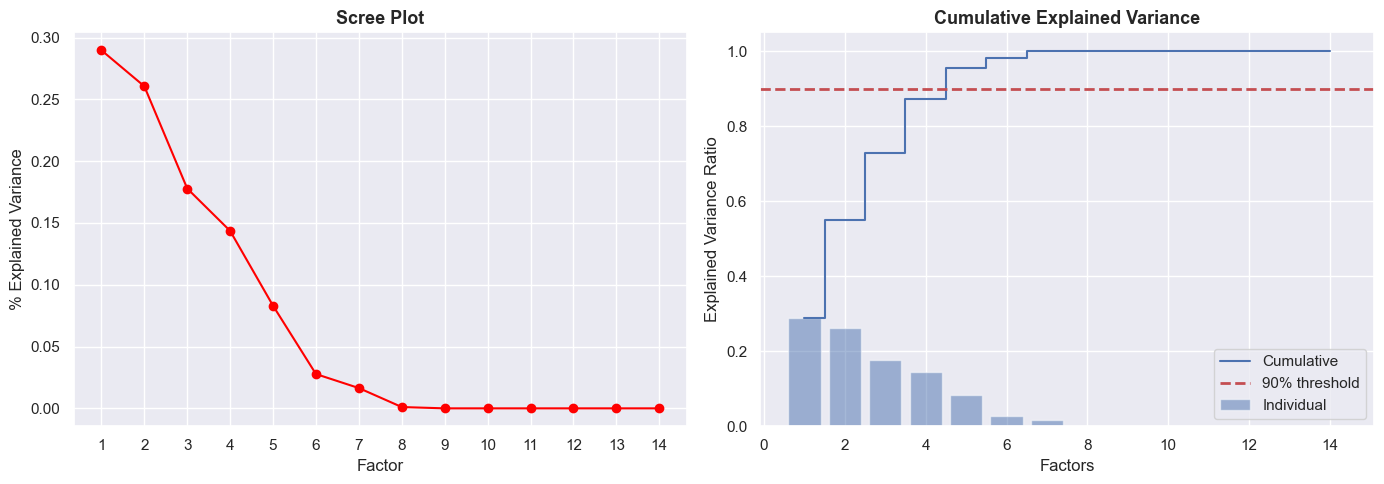

In [22]:
# Scree + Cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, c='red', marker='o')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('% Explained Variance')
axes[0].set_title('Scree Plot', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, len(explained_variance_ratio)+1))

cumulative = [explained_variance_ratio[:y].sum() for y in range(1, len(explained_variance_ratio)+1)]
axes[1].bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.5, label='Individual')
axes[1].step(range(1, len(explained_variance_ratio)+1), cumulative, where='mid', label='Cumulative')
axes[1].axhline(y=0.90, linewidth=2, color='r', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Factors')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

**Scree Plot Interpretation:**  
The elbow in the scree plot indicates the point where adding more factors gives diminishing
returns on explained variance. The cumulative chart confirms how many factors are needed to
cross the 90% threshold — in our case 4 factors. Beyond that point, additional factors
capture noise rather than meaningful structure in the data.

In [23]:
VARIANCE_TO_KEEP = 0.90
n_components = [explained_variance_ratio[:y].sum() > VARIANCE_TO_KEEP
                for y in range(1, sklearn_fa.n_components+1)].count(False)
print(f'Factors to retain {VARIANCE_TO_KEEP*100:.0f}% variance: {n_components} out of {sklearn_fa.n_components}')

sklearn_fa_final = FactorAnalysis(n_components)
Y_sklearn_final = sklearn_fa_final.fit_transform(X_std)

# Sort factors by variance — sklearn does NOT do this automatically
actual_variances = np.sum(np.square(sklearn_fa_final.components_), axis=1)
idx_sorted = np.argsort(actual_variances)[::-1]
Y_sklearn_final = Y_sklearn_final[:, idx_sorted]
sklearn_fa_final.components_ = sklearn_fa_final.components_[idx_sorted]
print('Factors sorted by explained variance (most informative first).')

Factors to retain 90% variance: 4 out of 14
Factors sorted by explained variance (most informative first).


In [24]:
# Factor Loadings
def Factor_Loadings(fa_model, feature_names, threshold=0.3):
    dfloadings = pd.DataFrame(
        data=fa_model.components_,
        columns=feature_names,
        index=[f'F{n+1}' for n in range(fa_model.n_components)]
    )
    return dfloadings.T.where(abs(dfloadings.T) > threshold, '')

print('Factor Loadings (showing |loading| > 0.3):')
Factor_Loadings(sklearn_fa_final, fa_features, threshold=0.3)

Factor Loadings (showing |loading| > 0.3):


,F1,F2,F3,F4
Age,,,,
Weight (kg),,0.855,,
Height (m),,,,0.478
Max_BPM,,,-0.565,
Avg_BPM,,,0.844,
Resting_BPM,,,,
Session_Duration (hours),-0.997,,,
Fat_Percentage,0.587,,,-0.467
Water_Intake (liters),,,,0.895
Experience_Level,-0.766,,,


In [25]:
# Communalities: % of each variable's variance explained by the retained factors
dfloadings_numeric = pd.DataFrame(
    data    = sklearn_fa_final.components_,
    columns = fa_features,
    index   = [f'F{n+1}' for n in range(n_components)]
).T

commun = (dfloadings_numeric ** 2).sum(axis=1)
dfcommun = pd.DataFrame(commun, index=dfloadings_numeric.index, columns=['Communality'])
dfcommun = dfcommun.sort_values('Communality', ascending=False)

print('Communalities — % of each variable\'s variance explained by the factors:')
dfcommun.style.format('{:.2%}')

Communalities — % of each variable's variance explained by the factors:


,Communality
HR_Intensity_Ratio,99.87%
BMI,99.77%
Session_Duration (hours),99.74%
Water_Intake (liters),93.14%
Session_Water_Ratio,91.96%
Weight (kg),78.59%
Avg_BPM,71.51%
Experience_Level,59.89%
Fat_Percentage,57.18%
BMI_Age_Interaction,40.14%


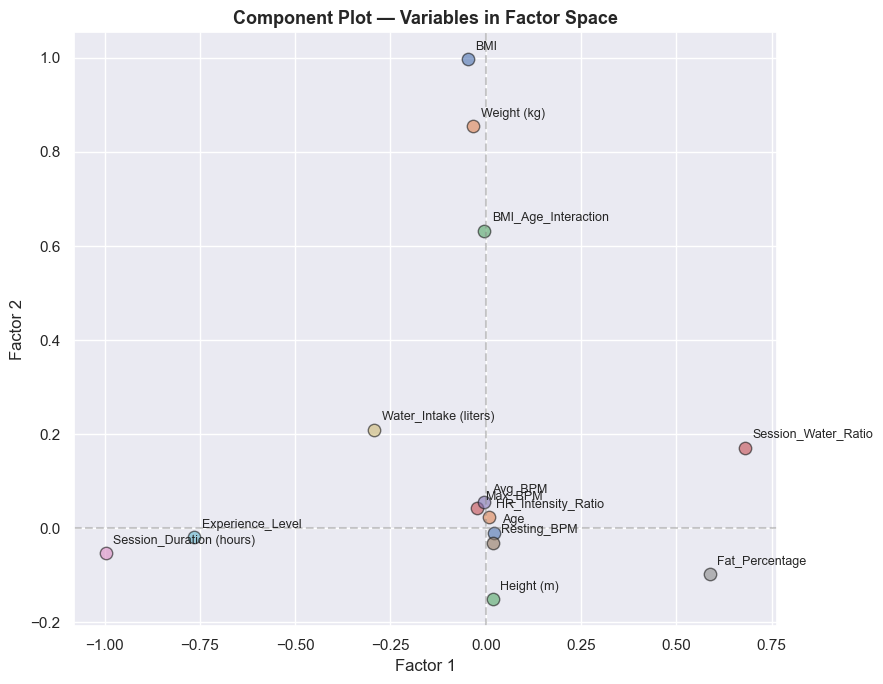

In [26]:
# Component plot: variables in F1 vs F2 factor space
loadings_raw = sklearn_fa_final.components_.T
df_plot = pd.DataFrame(loadings_raw[:, :2], columns=['F1', 'F2'], index=fa_features)

plt.figure(figsize=(9, 7))
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.4)
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.4)

for i, varname in enumerate(df_plot.index):
    plt.scatter(df_plot['F1'].iloc[i], df_plot['F2'].iloc[i],
                s=80, edgecolors='k', alpha=0.6)
    plt.text(df_plot['F1'].iloc[i] + 0.02, df_plot['F2'].iloc[i] + 0.02,
             varname, fontsize=9)

plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Component Plot — Variables in Factor Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Using FA Factors as Features

The FA above (Section 6) was run on the **full dataset** purely to explore the latent 
structure of all features before modelling — it is **not** used to generate features 
for any model.

After the train/test split (Section 7) and RFECV feature selection (Section 7.2), 
FA is **re-run exclusively on the training set** using only the 9 RFECV-selected 
features. This ensures:
- No data leakage (scaler and FA fitted only on train)
- FA reflects the actual modelling feature space, not all original variables
- Factor scores fed into models are computed properly post-split

This comparison appears in **Section 7.4 and 7.5**.
```


In [27]:
# Factor scores will be computed post-split in Section 7.5
# (Nothing to run here — this cell intentionally left as a placeholder)
print('FA modelling comparison will run in Section 7.5, after train/test split.')

FA modelling comparison will run in Section 7.5, after train/test split.


---
## 7. Train / Test Split

In [28]:
feature_cols = [c for c in df_model.columns if c != target]
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def class_perc(data, label=''):
    lendata = len(data)
    classes = Counter(data)
    print(label)
    for sclass, freq in sorted(classes.items()):
        name = 'High Performer' if sclass == 1 else 'Low Performer'
        print(f"  '{name}': {(freq/lendata)*100:.2f}%")

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}\n')
class_perc(Y_train, 'Training set:')
print()
class_perc(Y_test, 'Testing set:')

Training set: (778, 18)
Testing set:  (195, 18)

Training set:
  'Low Performer': 55.53%
  'High Performer': 44.47%

Testing set:
  'Low Performer': 55.38%
  'High Performer': 44.62%


In [29]:
# Scale features (required for KNN; also used by other models for fairness)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)
print('Features scaled successfully.')

Features scaled successfully.


---
## 7.2 Feature Selection — RFECV

**Why feature selection?**
Not all 18 features contribute equally to predicting High Performers. Redundant or noisy 
features can hurt generalisation and increase model complexity. We use Recursive Feature 
Elimination with Cross-Validation (RFECV) to identify the optimal subset of features.

RFECV trains a model repeatedly, removing the weakest feature at each step, and uses 
5-fold CV to find the number of features that maximises Recall on the training set.
We use Random Forest as the estimator since it handles mixed feature types well and 
provides reliable importance scores.

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

Optimal number of features: 9 out of 18

Selected features:
  ✓ Weight (kg)
  ✓ Avg_BPM
  ✓ Session_Duration (hours)
  ✓ Fat_Percentage
  ✓ Water_Intake (liters)
  ✓ Experience_Level
  ✓ HR_Intensity_Ratio
  ✓ BMI_Age_Interaction
  ✓ Session_Water_Ratio

Eliminated features:
  ✗ Age
  ✗ Height (m)
  ✗ Max_BPM
  ✗ Resting_BPM
  ✗ BMI
  ✗ Gender_Male
  ✗ Workout_Type_HIIT
  ✗ Workout_Type_Strength
  ✗ Workout_Type_Yoga


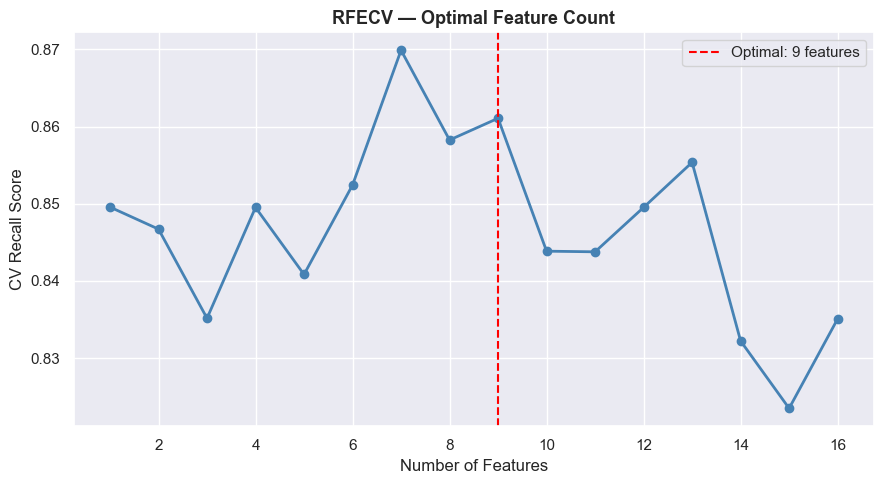

In [30]:
from sklearn.feature_selection import RFECV

rfecv_estimator = RandomForestClassifier(
    n_estimators=50, random_state=42, class_weight='balanced'
)

rfecv = RFECV(
    estimator=rfecv_estimator,
    step=1,
    cv=5,
    scoring='recall',
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train, Y_train)

selected_features = X_train.columns[rfecv.support_].tolist()
eliminated_features = X_train.columns[~rfecv.support_].tolist()

print(f'Optimal number of features: {rfecv.n_features_} out of {X_train.shape[1]}')
print(f'\nSelected features:')
for f in selected_features:
    print(f'  ✓ {f}')
print(f'\nEliminated features:')
for f in eliminated_features:
    print(f'  ✗ {f}')

# Plot CV score vs number of features
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(rfecv.n_features_, color='red', linestyle='--',
            label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel('Number of Features')
plt.ylabel('CV Recall Score')
plt.title('RFECV — Optimal Feature Count', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Rebuild train/test sets using only selected features
X_train_rfecv = X_train[selected_features]
X_test_rfecv  = X_test[selected_features]

# Scaled versions for KNN and Naive Bayes — use a dedicated scaler to avoid overwriting the original
scaler_rfecv = StandardScaler()
X_train_rfecv_scaled = pd.DataFrame(
    scaler_rfecv.fit_transform(X_train_rfecv), columns=selected_features
)
X_test_rfecv_scaled = pd.DataFrame(
    scaler_rfecv.transform(X_test_rfecv), columns=selected_features
)

print(f'Feature space reduced: {X_train.shape[1]} → {X_train_rfecv.shape[1]} features')
print('These selected features will be used for all final model evaluations.')

Feature space reduced: 18 → 9 features
These selected features will be used for all final model evaluations.


### 7.3 VIF — Post-RFECV Multicollinearity Check

With the feature space reduced from 18 to 9, we re-run VIF to confirm that multicollinearity 
persists among the selected features — validating that Factor Analysis on this reduced set 
is still justified.

In [32]:
# VIF on the 9 RFECV-selected features
vif_rfecv = pd.DataFrame()
vif_rfecv['Variable'] = selected_features
vif_rfecv['VIF'] = [
    variance_inflation_factor(X_train_rfecv.values, i)
    for i in range(X_train_rfecv.shape[1])
]
vif_rfecv = vif_rfecv.sort_values('VIF', ascending=False)

print('VIF on RFECV-selected features (VIF > 5 suggests multicollinearity):')
print(vif_rfecv.to_string(index=False))

VIF on RFECV-selected features (VIF > 5 suggests multicollinearity):
                Variable     VIF
                 Avg_BPM 332.650
      HR_Intensity_Ratio 240.807
   Water_Intake (liters) 102.245
Session_Duration (hours)  99.516
     Session_Water_Ratio  49.775
          Fat_Percentage  22.970
             Weight (kg)  21.426
        Experience_Level  20.060
     BMI_Age_Interaction   8.909


### 7.4 Factor Analysis — Re-run on RFECV-Selected Features

Following RFECV, Age, Resting_BPM, Height (m), Max_BPM, BMI, and all dummy variables were eliminated.
Per best practice, FA is re-run exclusively on the 9 selected features to ensure the latent structure
and n_components reflect the actual modelling feature space.

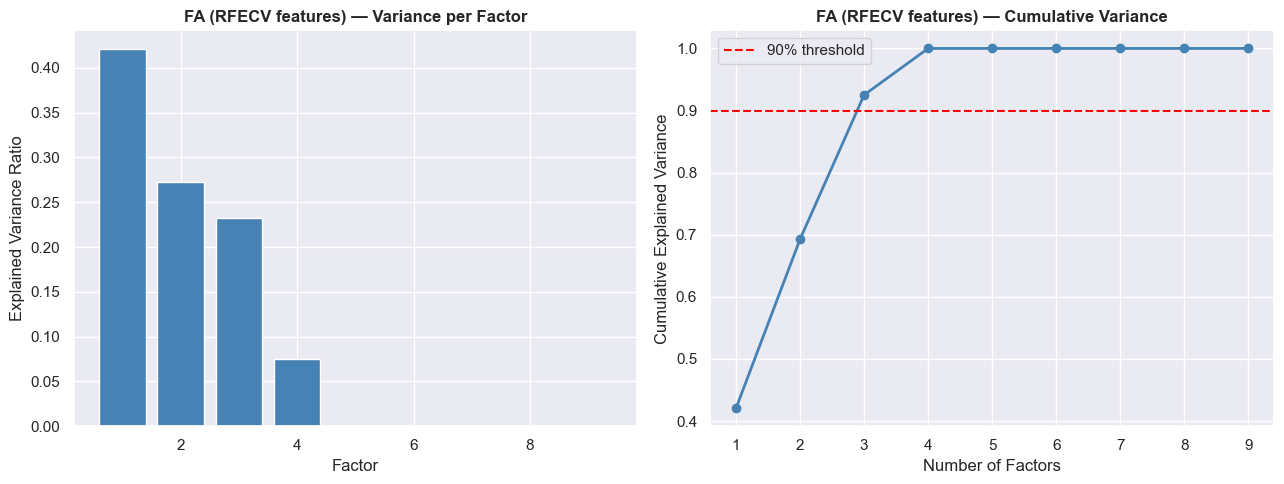

Factors to retain 90% variance (RFECV features): 3 out of 9

Factor Loadings on RFECV features (showing |loading| > 0.3):


,F1,F2,F3
Weight (kg),,0.387,
Avg_BPM,,,0.921
Session_Duration (hours),-0.968,,
Fat_Percentage,0.458,-0.609,
Water_Intake (liters),,0.925,
Experience_Level,-0.723,,
HR_Intensity_Ratio,,,0.916
BMI_Age_Interaction,,,
Session_Water_Ratio,0.835,0.521,


In [33]:
# ── FA RE-RUN on RFECV-selected features only ──────────────────────────────

# Step 1: Standardise the RFECV feature set (training data only)
fa_ss2 = StandardScaler()
X_train_rfecv_std = fa_ss2.fit_transform(X_train_rfecv)
X_test_rfecv_std  = fa_ss2.transform(X_test_rfecv)

# Step 2: Fit full FA to get explained variance per factor
sklearn_fa2_full = FactorAnalysis(len(selected_features), random_state=42)
sklearn_fa2_full.fit(X_train_rfecv_std)

squared_loadings2       = np.sum(np.square(sklearn_fa2_full.components_), axis=1)
expl_var_ratio2         = squared_loadings2 / np.sum(squared_loadings2)
cumulative_var2         = np.cumsum(expl_var_ratio2)

# Step 3: Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(expl_var_ratio2)+1), expl_var_ratio2, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('FA (RFECV features) — Variance per Factor', fontweight='bold')

axes[1].plot(range(1, len(cumulative_var2)+1), cumulative_var2, marker='o', color='steelblue', linewidth=2)
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Factors')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('FA (RFECV features) — Cumulative Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Step 4: Select n_components to retain 90% variance
VARIANCE_TO_KEEP = 0.90
n_components2 = int(np.argmax(cumulative_var2 >= VARIANCE_TO_KEEP)) + 1
print(f'Factors to retain {VARIANCE_TO_KEEP*100:.0f}% variance (RFECV features): {n_components2} out of {len(selected_features)}')

# Step 5: Fit final FA with selected n_components
sklearn_fa2_final = FactorAnalysis(n_components2, random_state=42)
X_train_fa2 = sklearn_fa2_final.fit_transform(X_train_rfecv_std)
X_test_fa2  = sklearn_fa2_final.transform(X_test_rfecv_std)

# Step 6: Factor loadings table
loadings2_df = pd.DataFrame(
    data    = sklearn_fa2_final.components_,
    columns = selected_features,
    index   = [f'F{n+1}' for n in range(n_components2)]
).T

print('\nFactor Loadings on RFECV features (showing |loading| > 0.3):')
loadings2_df.where(abs(loadings2_df) > 0.3, '')

## 7.5 FA-Reduced Feature Space — Model Comparison

We train Gradient Boosting on the FA-reduced feature space (3 factors) and compare its AUC 
against the RFECV 9-feature model. This tests whether dimension reduction retains predictive 
power — a key question for deployment in a gym's CRM system.

In [34]:
# FA comparison: RFECV 9-feature model vs FA-reduced model (both on same feature set)
gb_fa2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_fa2.fit(X_train_fa2, Y_train)
p_fa2   = gb_fa2.predict_proba(X_test_fa2)[:, 1]
auc_fa2 = roc_auc_score(Y_test, p_fa2)

gb_rfecv = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_rfecv.fit(X_train_rfecv, Y_train)
p_rfecv   = gb_rfecv.predict_proba(X_test_rfecv)[:, 1]
auc_rfecv = roc_auc_score(Y_test, p_rfecv)

print('=== FA Dimensionality Reduction — Impact on Performance ===')
print(f'  RFECV feature space : {len(selected_features):>2} features  → Test AUC = {auc_rfecv:.3f}')
print(f'  FA-reduced space    : {n_components2:>2} factors    → Test AUC = {auc_fa2:.3f}')
print(f'  AUC difference      :               {auc_rfecv - auc_fa2:+.3f}')
print()
if abs(auc_rfecv - auc_fa2) < 0.02:
    print('Conclusion: FA retains nearly all predictive power with far fewer features.')
    print('The reduced model is preferable for deployment (simpler, faster, interpretable).')
else:
    print('Conclusion: Full RFECV feature space outperforms FA-reduced model.')
    print('FA is valuable for understanding latent structure, but the RFECV model should be deployed.')

=== FA Dimensionality Reduction — Impact on Performance ===
  RFECV feature space :  9 features  → Test AUC = 0.970
  FA-reduced space    :  3 factors    → Test AUC = 0.933
  AUC difference      :               +0.037

Conclusion: Full RFECV feature space outperforms FA-reduced model.
FA is valuable for understanding latent structure, but the RFECV model should be deployed.


---
## 8. Evaluation Helper Functions

In [35]:
def evaluate_model(model, X_tr, X_te, Y_tr, Y_te, model_name='Model', cutoff=0.5):
    probs_train = model.predict_proba(X_tr)[:, 1]
    probs_test  = model.predict_proba(X_te)[:, 1]
    preds_train = (probs_train >= cutoff).astype(int)
    preds_test  = (probs_test  >= cutoff).astype(int)

    results = pd.DataFrame({
        'Metric': ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Train': [
            roc_auc_score(Y_tr, probs_train),
            accuracy_score(Y_tr, preds_train),
            precision_score(Y_tr, preds_train, zero_division=0),
            recall_score(Y_tr, preds_train),
            f1_score(Y_tr, preds_train)
        ],
        'Test': [
            roc_auc_score(Y_te, probs_test),
            accuracy_score(Y_te, preds_test),
            precision_score(Y_te, preds_test, zero_division=0),
            recall_score(Y_te, preds_test),
            f1_score(Y_te, preds_test)
        ]
    }).set_index('Metric')

    print(f'\n--- {model_name} ---')
    print(results.round(3))

    # Classification report
    print(f'\n--- {model_name} — Classification Report (Test) ---')
    print(classification_report(Y_te, preds_test,
          target_names=['Low Performer', 'High Performer']))
    
    # Raw + normalized confusion matrices + ROC curve
    cm      = confusion_matrix(Y_te, preds_test)
    cm_norm = confusion_matrix(Y_te, preds_test, normalize='true')
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix (counts)', fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    axes[1].set_title(f'{model_name}\nConfusion Matrix (normalized)', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(Y_te, probs_test)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[2].plot([0,1],[0,1], color='grey', linestyle='--')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title(f'{model_name} — ROC Curve', fontweight='bold')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return results

# Store results for final comparison
all_results = {}
measure = 'recall'  # Primary metric: recall — missing a High Performer is costlier than a false alarm
print(f'Primary scoring metric: {measure}')

Primary scoring metric: recall


---
## 9. Model 0 — Decision Tree (Baseline)

**Business Rationale:**  
Before applying ensemble methods, we establish a single Decision Tree as a baseline. Trees are highly interpretable — a gym manager can follow the exact rules the model uses to classify a member. The baseline also lets us quantify how much ensembles improve over a single tree, justifying the added complexity.

We apply two pruning strategies: **GridSearchCV** (limiting depth and leaf size) and **Cost Complexity Pruning (CCP alpha)**, exactly as covered in class.

Recall that for tree models we will use all of the features, not the FA components selected nor the RFECV-selected features.

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# --- Initial unpruned tree ---
my_tree = DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced')
my_tree.fit(X_train, Y_train)

print(f'Unpruned tree — nodes: {my_tree.tree_.node_count}, '
      f'depth: {my_tree.get_depth()}, leaves: {my_tree.get_n_leaves()}')

probs_test = my_tree.predict_proba(X_test)[:, 1]
print(f'Unpruned tree — Test AUC: {roc_auc_score(Y_test, probs_test):.3f}, '
      f'Recall: {recall_score(Y_test, (probs_test>=0.5).astype(int)):.3f}')

# Train vs Test — motivates pruning
probs_train_ut = my_tree.predict_proba(X_train)[:, 1]
preds_train_ut = (probs_train_ut >= 0.5).astype(int)
preds_test_ut  = (probs_test    >= 0.5).astype(int)

ov_df = pd.DataFrame({
    'Metric': ['AUC', 'Recall', 'F1'],
    'Train':  [roc_auc_score(Y_train, probs_train_ut),
               recall_score(Y_train, preds_train_ut),
               f1_score(Y_train, preds_train_ut)],
    'Test':   [roc_auc_score(Y_test, probs_test),
               recall_score(Y_test, preds_test_ut),
               f1_score(Y_test, preds_test_ut)]
}).set_index('Metric')

ov_df['Gap'] = ov_df['Train'] - ov_df['Test']
print('\nUnpruned tree — overfitting check:')
print(ov_df.round(3))
print('\n→ Large gap confirms overfitting. Pruning required.')


Unpruned tree — nodes: 125, depth: 12, leaves: 63
Unpruned tree — Test AUC: 0.826, Recall: 0.828

Unpruned tree — overfitting check:
        Train  Test   Gap
Metric                   
AUC     1.000 0.826 0.174
Recall  1.000 0.828 0.172
F1      1.000 0.809 0.191

→ Large gap confirms overfitting. Pruning required.


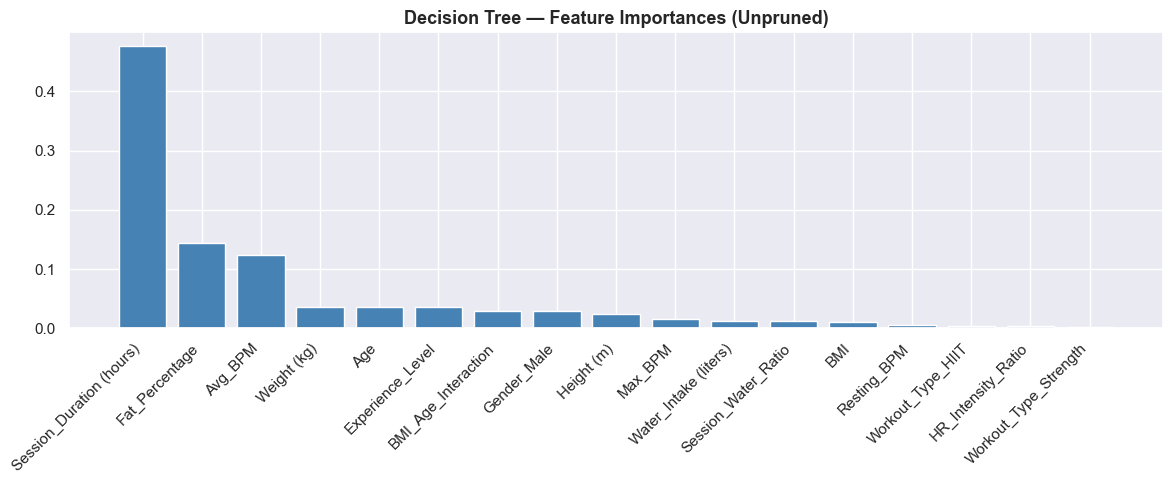

In [37]:
# Feature importances — initial tree
importances_dt = my_tree.feature_importances_
mask = importances_dt > 0.001
filt_imp = importances_dt[mask]
filt_cols = X_train.columns[mask]
indices = np.argsort(filt_imp)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(filt_cols[indices], filt_imp[indices], color='steelblue', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Decision Tree — Feature Importances (Unpruned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [38]:
# --- Pruning Strategy 1: GridSearchCV ---
param_grid_tree = {
    'max_depth': range(3, 10),
    'min_samples_leaf': [3, 5, 7, 9]
}

tree_cv = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'),
    param_grid_tree, scoring=measure, refit=True, cv=5, return_train_score=True
)
tree_cv.fit(X_train, Y_train)

print('Best parameters (Decision Tree):', tree_cv.best_params_)
print(f'Best CV {measure}: {tree_cv.best_score_:.3f}')

# CV results table
cv_tree = pd.DataFrame(tree_cv.cv_results_)[[
    'param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False).head(8).round(3)
cv_tree.columns = ['Max Depth', 'Min Samples Leaf', f'Mean CV {measure.capitalize()}', 'Std']
print('\nTop 8 hyperparameter combinations:')
cv_tree


Best parameters (Decision Tree): {'max_depth': 4, 'min_samples_leaf': 9}
Best CV recall: 0.899

Top 8 hyperparameter combinations:


,Max Depth,Min Samples Leaf,Mean CV Recall,Std
7,4,9,0.899,0.054
4,4,3,0.887,0.042
5,4,5,0.887,0.042
6,4,7,0.887,0.042
9,5,5,0.870,0.047
12,6,3,0.870,0.053
8,5,3,0.867,0.053
10,5,7,0.867,0.043


Best CCP alpha: 0.09896


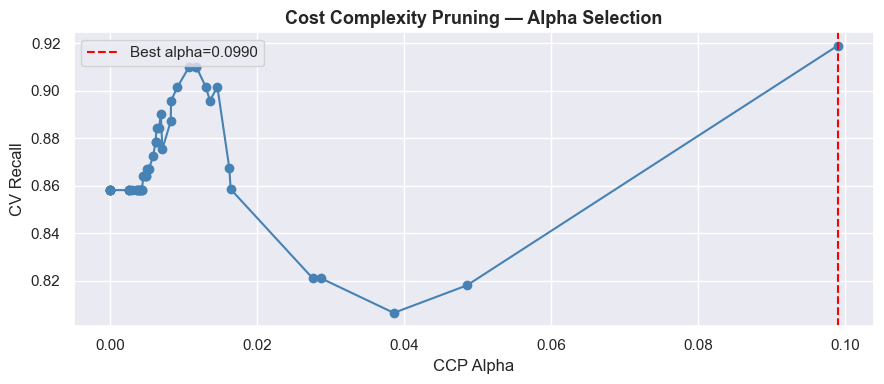

In [39]:
# --- Pruning Strategy 2: Cost Complexity Pruning ---
path = DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'
                               ).fit(X_train, Y_train).cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = np.maximum(path.ccp_alphas[:-1], 0)

cv_scores_ccp = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42,
                                  class_weight='balanced', ccp_alpha=alpha)
    score = cross_val_score(clf, X_train, Y_train, cv=5, scoring=measure).mean()
    cv_scores_ccp.append(score)

best_alpha = ccp_alphas[np.argmax(cv_scores_ccp)]
print(f'Best CCP alpha: {best_alpha:.5f}')

plt.figure(figsize=(9, 4))
plt.plot(ccp_alphas, cv_scores_ccp, marker='o', color='steelblue')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha:.4f}')
plt.xlabel('CCP Alpha')
plt.ylabel(f'CV {measure.capitalize()}')
plt.title('Cost Complexity Pruning — Alpha Selection', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# Train the CCP-pruned tree with the best alpha
tree_ccp = DecisionTreeClassifier(
    criterion='entropy', random_state=42,
    class_weight='balanced', ccp_alpha=best_alpha
)
tree_ccp.fit(X_train, Y_train)

# Compare all three: Unpruned vs GridSearch vs CCP
def tree_metrics(t):
    p = t.predict_proba(X_test)[:, 1]
    return roc_auc_score(Y_test, p), recall_score(Y_test, (p >= 0.5).astype(int))

auc_u,  rec_u  = tree_metrics(my_tree)
auc_cv, rec_cv = tree_metrics(tree_cv.best_estimator_)
auc_cp, rec_cp = tree_metrics(tree_ccp)

comparison = pd.DataFrame({
    'Model Stage': ['Unpruned', 'GridSearch Pruned', 'CCP Pruned'],
    'Nodes':  [my_tree.tree_.node_count,
               tree_cv.best_estimator_.tree_.node_count,
               tree_ccp.tree_.node_count],
    'Leaves': [my_tree.get_n_leaves(),
               tree_cv.best_estimator_.get_n_leaves(),
               tree_ccp.get_n_leaves()],
    'Test Recall': [rec_u, rec_cv, rec_cp],
    'Test AUC':    [auc_u, auc_cv, auc_cp]
})

print('=== Pruning Strategy Comparison ===')
comparison.set_index('Model Stage').round(3)

=== Pruning Strategy Comparison ===


,Nodes,Leaves,Test Recall,Test AUC
Model Stage,,,,
Unpruned,125,63,0.828,0.826
GridSearch Pruned,21,11,0.931,0.959
CCP Pruned,3,2,0.931,0.831



--- Decision Tree (Pruned) ---
           Train  Test
Metric                
ROC AUC    0.967 0.959
Accuracy   0.886 0.841
Precision  0.837 0.764
Recall     0.922 0.931
F1-Score   0.878 0.839

--- Decision Tree (Pruned) — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.93      0.77      0.84       108
High Performer       0.76      0.93      0.84        87

      accuracy                           0.84       195
     macro avg       0.85      0.85      0.84       195
  weighted avg       0.86      0.84      0.84       195



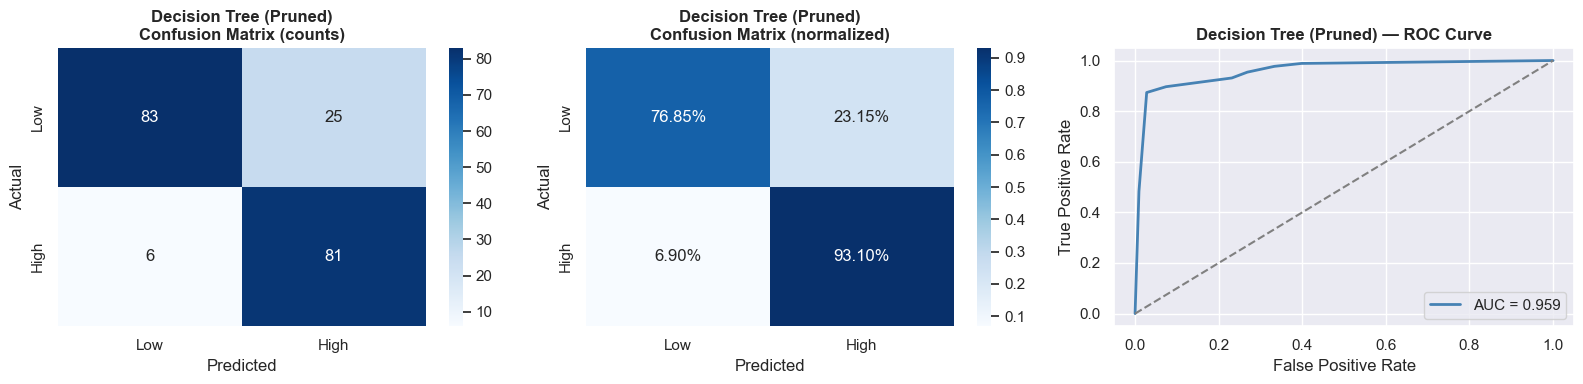

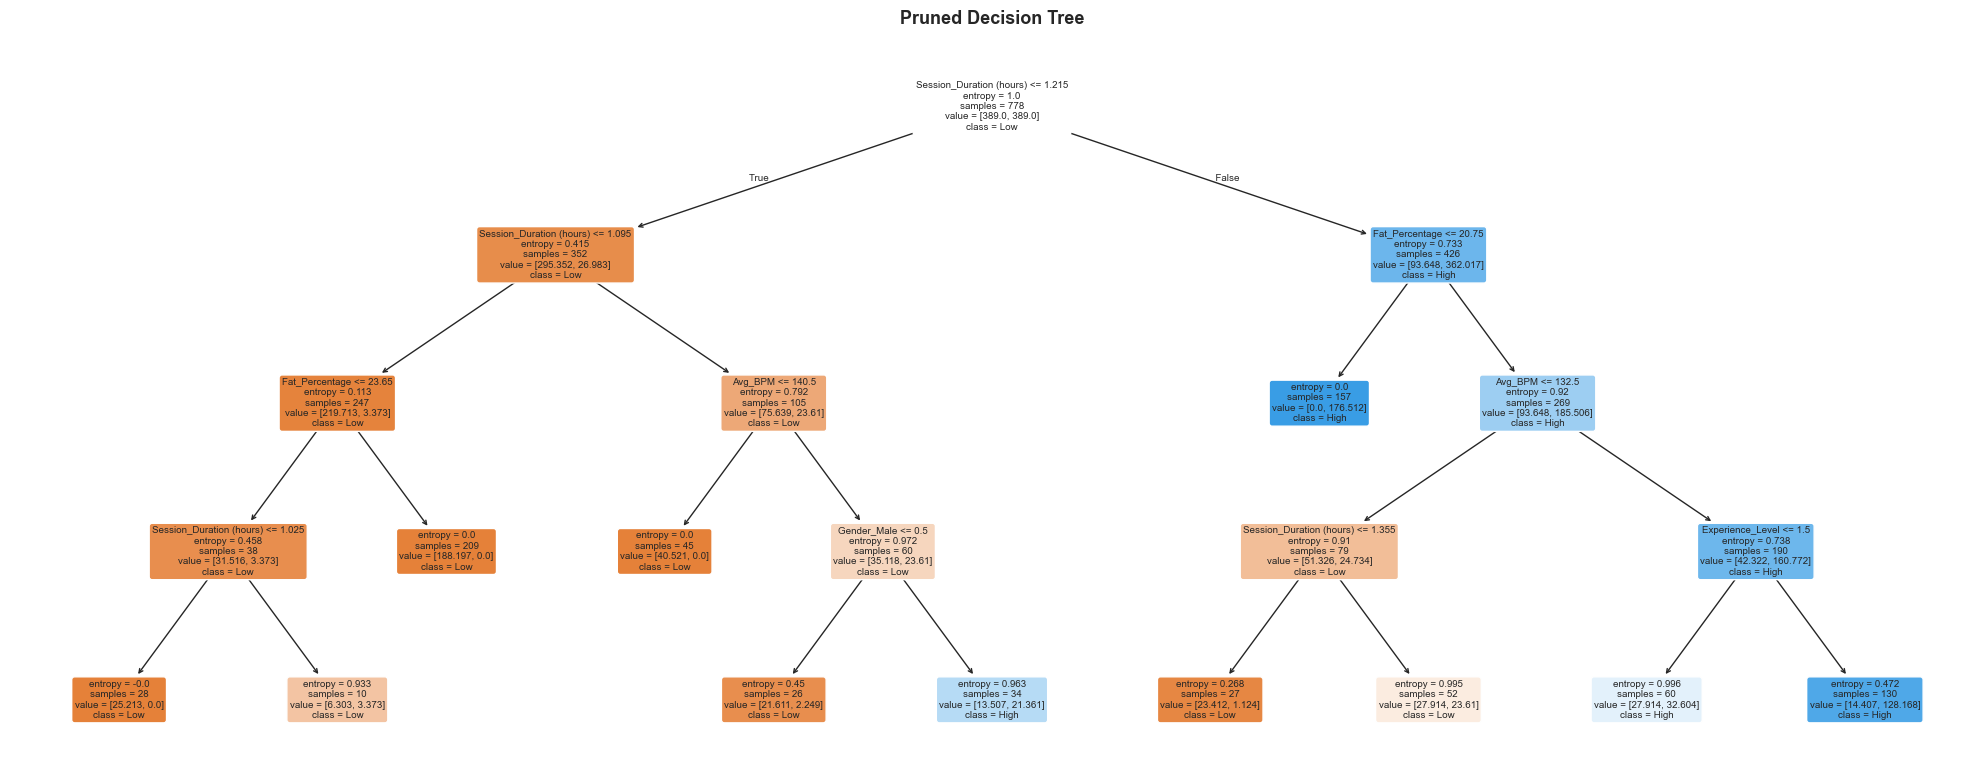

In [41]:
# Final pruned tree — best of GridSearch vs CCP
tree_pruned = tree_cv.best_estimator_

all_results['Decision Tree'] = evaluate_model(
    tree_pruned, X_train, X_test, Y_train, Y_test, 'Decision Tree (Pruned)'
)

# Visualise pruned tree
plt.figure(figsize=(20, 8))
plot_tree(tree_pruned, feature_names=X_train.columns,
          class_names=['Low', 'High'], filled=True, rounded=True, fontsize=7)
plt.title('Pruned Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10. Model 1 — Bagging Classifier

**Business Rationale:**  
Bagging reduces variance by training multiple decision trees on bootstrap samples. It produces a more stable and reliable classifier than a single tree — less sensitive to which specific members ended up in the training set.

In [42]:
# Base estimator parameters (max_depth=6, min_samples_leaf=5) are taken from the
# Decision Tree GridSearchCV best parameters above, providing a reasonable starting
# point. The BaggingClassifier grid search then optimises n_estimators, max_samples,
# and max_features on top of this base.

bagging_base = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42, class_weight='balanced',
        max_depth=6, min_samples_leaf=5
    ),
    random_state=42
)

param_grid_bagging = {
    'n_estimators': [50, 100, 200],
    'max_samples':  [0.6, 0.7, 0.8],
    'max_features': [0.7, 0.8, 1.0]
}

bagging_cv = GridSearchCV(
    bagging_base, param_grid_bagging,
    scoring=measure, refit=True, cv=5, return_train_score=True
)
bagging_cv.fit(X_train, Y_train)

print('Best parameters (Bagging):', bagging_cv.best_params_)
print(f'Best CV {measure}: {bagging_cv.best_score_:.3f}')

Best parameters (Bagging): {'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 50}
Best CV recall: 0.884



--- Bagging ---
           Train  Test
Metric                
ROC AUC    0.995 0.976
Accuracy   0.958 0.882
Precision  0.954 0.840
Recall     0.951 0.908
F1-Score   0.952 0.873

--- Bagging — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.92      0.86      0.89       108
High Performer       0.84      0.91      0.87        87

      accuracy                           0.88       195
     macro avg       0.88      0.88      0.88       195
  weighted avg       0.88      0.88      0.88       195



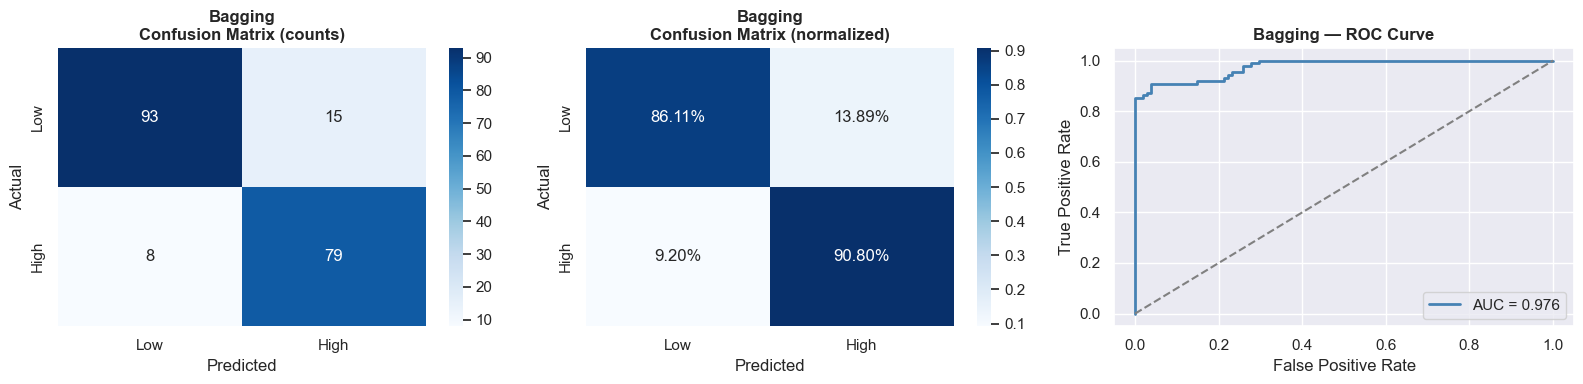

In [43]:
all_results['Bagging'] = evaluate_model(
    bagging_cv.best_estimator_, X_train, X_test, Y_train, Y_test, 'Bagging'
)

In [44]:
# Cross-validation results grid — shows how each hyperparameter combination performed
cv_results_bagging = pd.DataFrame(bagging_cv.cv_results_)[
    ['param_n_estimators', 'param_max_samples', 'param_max_features',
     'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(10).round(3)
cv_results_bagging.columns = ['N Estimators', 'Max Samples', 'Max Features', f'Mean CV {measure.capitalize()}', 'Std']
print('Top 10 Bagging hyperparameter combinations:')
cv_results_bagging

Top 10 Bagging hyperparameter combinations:


,N Estimators,Max Samples,Max Features,Mean CV Recall,Std
15,50,0.800,0.800,0.884,0.036
13,100,0.700,0.800,0.881,0.034
16,100,0.800,0.800,0.881,0.045
1,100,0.600,0.700,0.876,0.042
21,50,0.700,1.000,0.876,0.043
6,50,0.800,0.700,0.876,0.038
12,50,0.700,0.800,0.876,0.038
14,200,0.700,0.800,0.876,0.047
18,50,0.600,1.000,0.873,0.041
10,100,0.600,0.800,0.873,0.046


---
## 11. Model 2 — Random Forest

**Business Rationale:**  
Random Forest improves on Bagging by also randomizing feature selection at each split, reducing correlation between trees. It is one of the most robust classifiers for structured data like ours and provides **feature importances** that translate directly into actionable gym insights.

In [45]:
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [3, 5]
}

rf_cv = GridSearchCV(
    rf_base, param_grid_rf,
    scoring=measure, refit=True, cv=5, return_train_score=True
)
rf_cv.fit(X_train, Y_train)

print('Best parameters:', rf_cv.best_params_)
print(f'Best CV {measure}: {rf_cv.best_score_:.3f}')

Best parameters: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV recall: 0.890


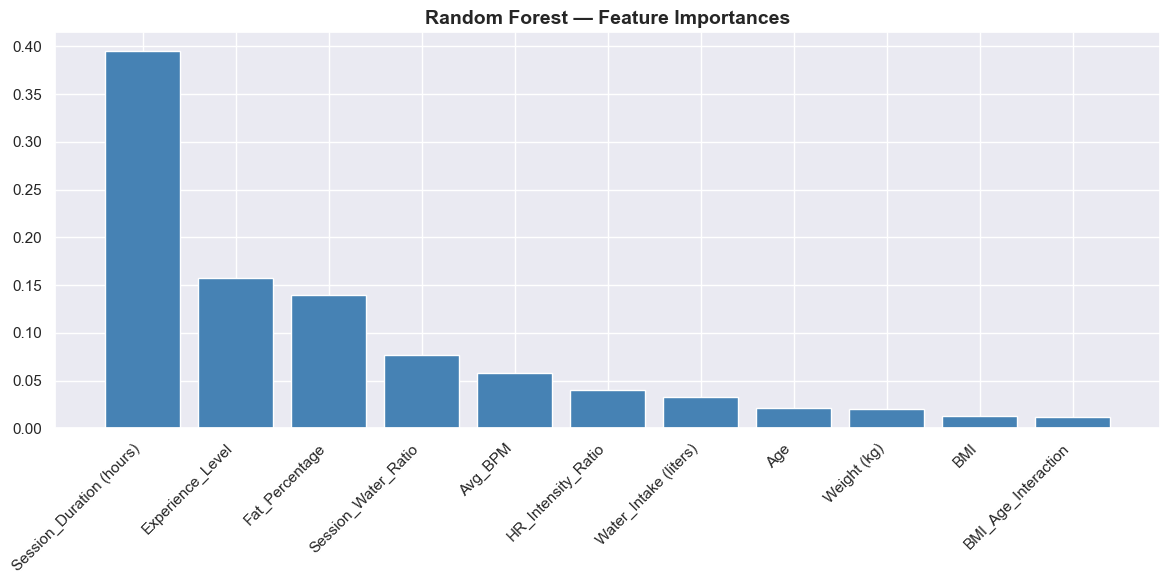

In [46]:
# Feature importances
importances = rf_cv.best_estimator_.feature_importances_
columns = X_train.columns
mask = importances > 0.01
filt_importances = importances[mask]
filt_columns = columns[mask]
indices = np.argsort(filt_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(filt_columns[indices], filt_importances[indices], color='steelblue', edgecolor='white')
plt.xticks(range(len(indices)), filt_columns[indices], rotation=45, ha='right')
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- Random Forest ---
           Train  Test
Metric                
ROC AUC    0.992 0.970
Accuracy   0.949 0.877
Precision  0.937 0.832
Recall     0.948 0.908
F1-Score   0.943 0.868

--- Random Forest — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.92      0.85      0.88       108
High Performer       0.83      0.91      0.87        87

      accuracy                           0.88       195
     macro avg       0.88      0.88      0.88       195
  weighted avg       0.88      0.88      0.88       195



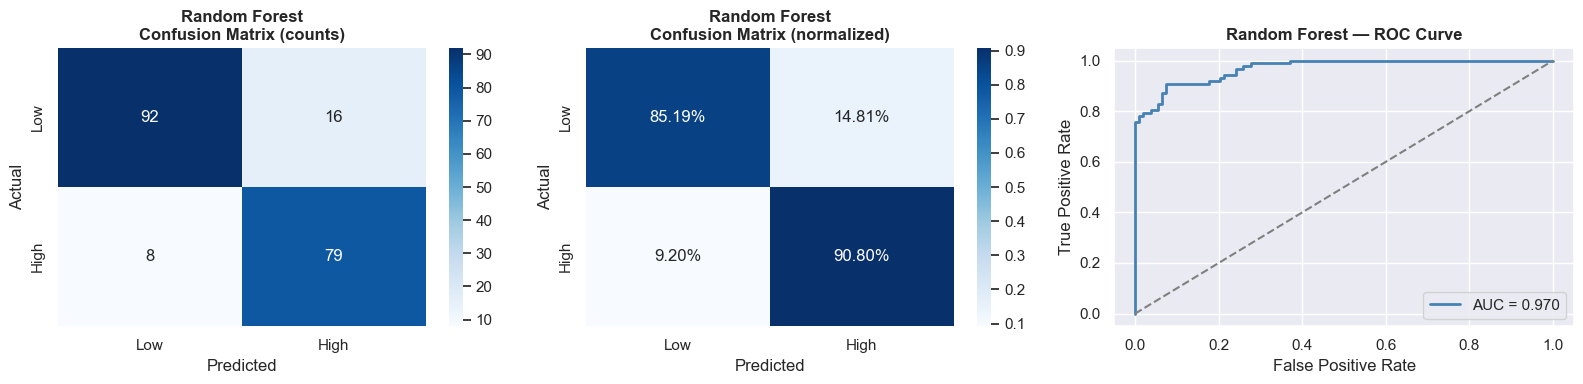

In [47]:
all_results['Random Forest'] = evaluate_model(
    rf_cv.best_estimator_, X_train, X_test, Y_train, Y_test, 'Random Forest'
)

In [48]:
cv_results_rf = pd.DataFrame(rf_cv.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
     'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(10).round(3)
cv_results_rf.columns = ['N Estimators', 'Max Depth', 'Min Samples Leaf', f'Mean CV {measure.capitalize()}', 'Std']
print('Top 10 Random Forest hyperparameter combinations:')
cv_results_rf

Top 10 Random Forest hyperparameter combinations:


,N Estimators,Max Depth,Min Samples Leaf,Mean CV Recall,Std
1,200,5,3,0.890,0.024
2,100,5,5,0.884,0.016
3,200,5,5,0.884,0.025
10,100,None,5,0.881,0.036
9,200,None,3,0.879,0.020
6,100,10,5,0.879,0.036
0,100,5,3,0.876,0.027
7,200,10,5,0.876,0.038
11,200,None,5,0.876,0.038
5,200,10,3,0.876,0.032


---
## 12. Model 3 — Gradient Boosting

**Business Rationale:**  
Boosting builds trees sequentially, each correcting the mistakes of the previous one. It typically achieves the highest predictive accuracy on structured data and is well-suited for capturing the nuanced profile of a high-performing gym member.


> **Note on class imbalance handling:** Unlike `DecisionTreeClassifier` and 
> `RandomForestClassifier`, sklearn's `GradientBoostingClassifier` does not accept 
> a `class_weight` parameter. Instead, imbalance is addressed through two mechanisms: 
> (1) GridSearchCV optimises for **Recall**, which directly penalises missed High 
> Performers, and (2) the `subsample` hyperparameter introduces stochastic sampling 
> at each boosting step, providing implicit regularisation that reduces bias toward 
> the majority class.

In [49]:
gb_base = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators':    [100, 200],
    'learning_rate':   [0.05, 0.1],
    'max_depth':       [2, 3],
    'subsample':       [0.7, 0.8],
    'min_samples_leaf':[5, 10]
}

gb_cv = GridSearchCV(
    gb_base, param_grid_gb,
    scoring=measure, refit=True, cv=5, return_train_score=True
)
gb_cv.fit(X_train, Y_train)

print('Best parameters (Gradient Boosting):', gb_cv.best_params_)
print(f'Best CV {measure}: {gb_cv.best_score_:.3f}')

Best parameters (Gradient Boosting): {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.8}
Best CV recall: 0.902



--- Gradient Boosting ---
           Train  Test
Metric                
ROC AUC    1.000 0.975
Accuracy   1.000 0.908
Precision  1.000 0.879
Recall     1.000 0.920
F1-Score   1.000 0.899

--- Gradient Boosting — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.93      0.90      0.92       108
High Performer       0.88      0.92      0.90        87

      accuracy                           0.91       195
     macro avg       0.91      0.91      0.91       195
  weighted avg       0.91      0.91      0.91       195



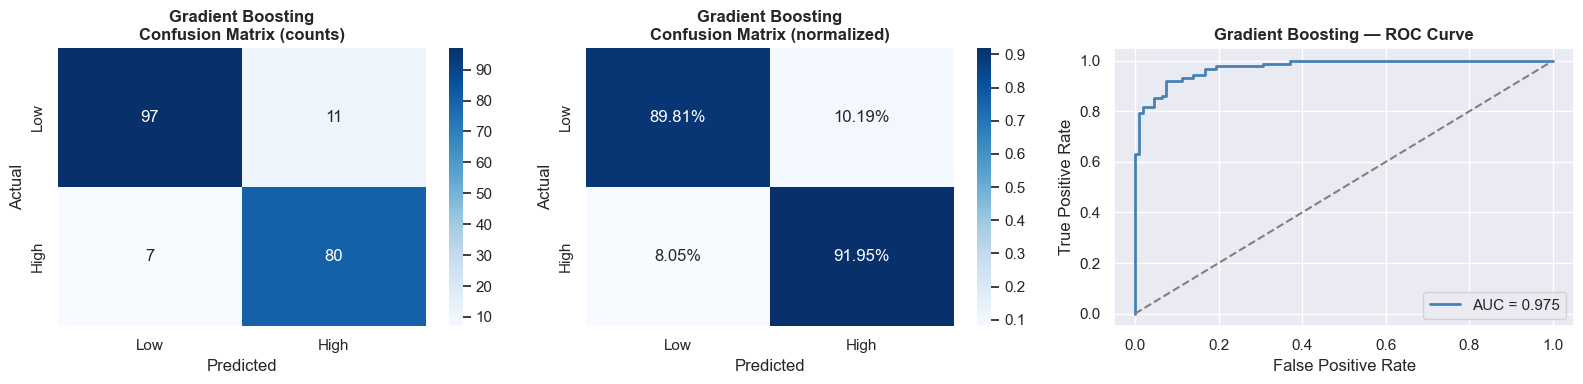

In [50]:
all_results['Gradient Boosting'] = evaluate_model(
    gb_cv.best_estimator_, X_train, X_test, Y_train, Y_test, 'Gradient Boosting'
)

In [51]:
cv_results_gb = pd.DataFrame(gb_cv.cv_results_)[
    ['param_n_estimators', 'param_learning_rate', 'param_max_depth',
     'param_subsample', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(10).round(3)
cv_results_gb.columns = ['N Est.', 'LR', 'Max Depth', 'Subsample', f'Mean CV {measure.capitalize()}', 'Std']
print('Top 10 Gradient Boosting hyperparameter combinations:')
cv_results_gb

Top 10 Gradient Boosting hyperparameter combinations:


,N Est.,LR,Max Depth,Subsample,Mean CV Recall,Std
31,200,0.100,3,0.800,0.902,0.042
30,200,0.100,3,0.700,0.902,0.046
26,200,0.100,3,0.700,0.902,0.031
28,100,0.100,3,0.700,0.902,0.031
29,100,0.100,3,0.800,0.899,0.026
15,200,0.050,3,0.800,0.890,0.034
11,200,0.050,3,0.800,0.887,0.030
27,200,0.100,3,0.800,0.887,0.031
24,100,0.100,3,0.700,0.887,0.041
5,100,0.050,2,0.800,0.884,0.031


---
## 13. Model 4 — K-Nearest Neighbors (KNN)

**Business Rationale:**  
KNN classifies a member based on similarity to existing members we already know. It is highly intuitive — a member is predicted "high performing" because their closest peers in the data are. Note: features **must be scaled** before applying KNN (done in Section 7).

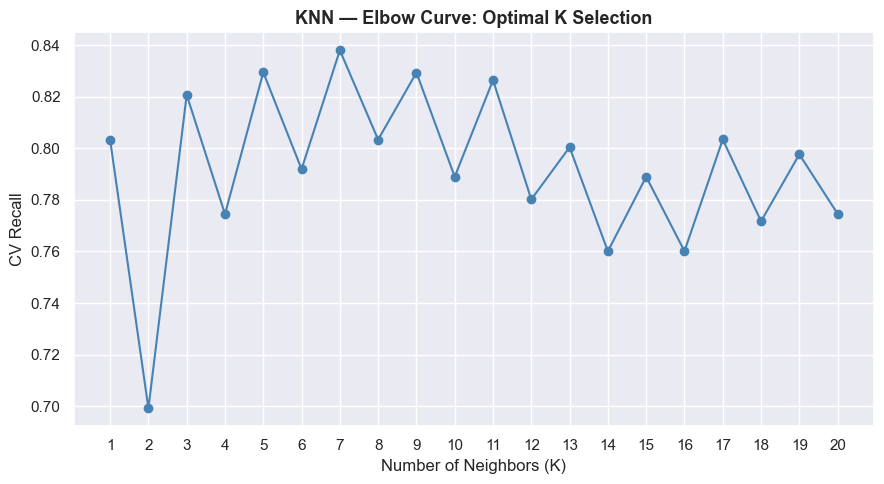

In [52]:
# Elbow curve: choosing optimal K
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_rfecv_scaled, Y_train, cv=5, scoring=measure)
    k_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel(f'CV {measure.capitalize()}')
plt.title('KNN — Elbow Curve: Optimal K Selection', fontsize=13, fontweight='bold')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [53]:
knn_base = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_cv = GridSearchCV(
    knn_base, param_grid_knn,
    scoring=measure, refit=True, cv=5, return_train_score=True
)
knn_cv.fit(X_train_rfecv_scaled, Y_train)  # Uses scaled features!

print('Best parameters:', knn_cv.best_params_)
print(f'Best CV {measure}: {knn_cv.best_score_:.3f}')

Best parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV recall: 0.850



--- KNN ---
           Train  Test
Metric                
ROC AUC    0.972 0.958
Accuracy   0.905 0.877
Precision  0.910 0.862
Recall     0.873 0.862
F1-Score   0.891 0.862

--- KNN — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.89      0.89      0.89       108
High Performer       0.86      0.86      0.86        87

      accuracy                           0.88       195
     macro avg       0.88      0.88      0.88       195
  weighted avg       0.88      0.88      0.88       195



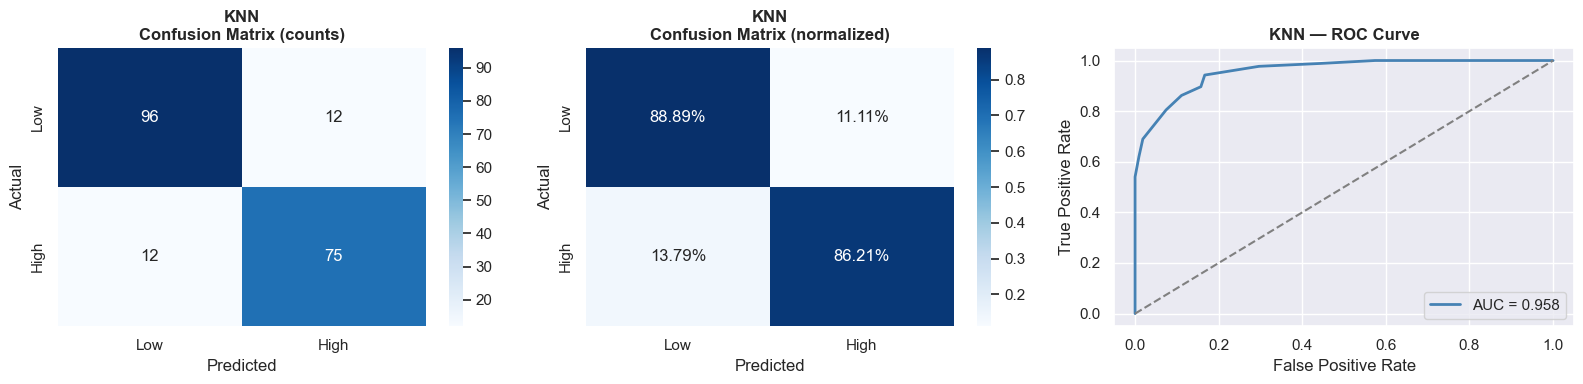

In [54]:
all_results['KNN'] = evaluate_model(
    knn_cv.best_estimator_, X_train_rfecv_scaled, X_test_rfecv_scaled, Y_train, Y_test, 'KNN'
)

In [55]:
cv_results_knn = pd.DataFrame(knn_cv.cv_results_)[[
    'param_n_neighbors', 'param_weights', 'param_metric',
    'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False).head(10).round(3)
cv_results_knn.columns = ['K', 'Weights', 'Metric', f'Mean CV {measure.capitalize()}', 'Std']
print('Top 10 KNN hyperparameter combinations:')
cv_results_knn


Top 10 KNN hyperparameter combinations:


,K,Weights,Metric,Mean CV Recall,Std
17,11,distance,manhattan,0.850,0.040
16,11,uniform,manhattan,0.850,0.039
14,7,uniform,manhattan,0.844,0.046
5,7,distance,euclidean,0.841,0.040
19,15,distance,manhattan,0.838,0.051
15,7,distance,manhattan,0.838,0.045
11,3,distance,manhattan,0.838,0.030
10,3,uniform,manhattan,0.838,0.030
4,7,uniform,euclidean,0.838,0.042
12,5,uniform,manhattan,0.832,0.035


---
## 14. Model 5 — Naïve Bayes

**Business Rationale:**  
Naïve Bayes applies Bayes' theorem assuming all features are independent given the class.
While this assumption is rarely perfectly true, the model is fast, robust to small datasets,
and provides a useful probabilistic baseline. It answers: *given this member's profile,
what is the probability they are a high performer?* — a natural framing for gym staff.

**Model choice — GaussianNB:**  
Unlike text classification tasks (e.g. spam detection) which use ComplementNB or MultinomialNB
for count data, our features here are continuous numerical measurements (BMI, BPM, session
duration, fat percentage). GaussianNB assumes features follow a Gaussian (normal) distribution
given the class — the correct assumption for continuous measurements. BernoulliNB is for binary
features; MultinomialNB and ComplementNB are for non-negative count data only.

In [56]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Tune var_smoothing — controls the portion of the largest variance added
# to variances for calculation stability (acts as regularisation)
nb_base = GaussianNB()

param_grid_nb = {
    'var_smoothing': np.logspace(-11, -1, 20)  # log-spaced search
}

nb_cv = GridSearchCV(
    nb_base, param_grid_nb,
    scoring=measure, refit=True, cv=5, return_train_score=True
)
nb_cv.fit(X_train_rfecv_scaled, Y_train)

print('Best parameters (Naive Bayes):', nb_cv.best_params_)
print(f'Best CV {measure}: {nb_cv.best_score_:.3f}')

# CV results
cv_results_nb = pd.DataFrame(nb_cv.cv_results_)[[
    'param_var_smoothing', 'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False).head(8).round(6)
cv_results_nb.columns = ['Var Smoothing', f'Mean CV {measure.capitalize()}', 'Std']
print('\nTop 8 var_smoothing values:')
cv_results_nb


Best parameters (Naive Bayes): {'var_smoothing': np.float64(1e-11)}
Best CV recall: 0.797

Top 8 var_smoothing values:


,Var Smoothing,Mean CV Recall,Std
0,0.000,0.797,0.065
9,0.000,0.797,0.065
16,0.003,0.797,0.065
15,0.001,0.797,0.065
14,0.000,0.797,0.065
13,0.000,0.797,0.065
12,0.000,0.797,0.065
11,0.000,0.797,0.065



--- Naive Bayes ---
           Train  Test
Metric                
ROC AUC    0.955 0.964
Accuracy   0.875 0.892
Precision  0.911 0.946
Recall     0.798 0.805
F1-Score   0.851 0.870

--- Naive Bayes — Classification Report (Test) ---
                precision    recall  f1-score   support

 Low Performer       0.86      0.96      0.91       108
High Performer       0.95      0.80      0.87        87

      accuracy                           0.89       195
     macro avg       0.90      0.88      0.89       195
  weighted avg       0.90      0.89      0.89       195



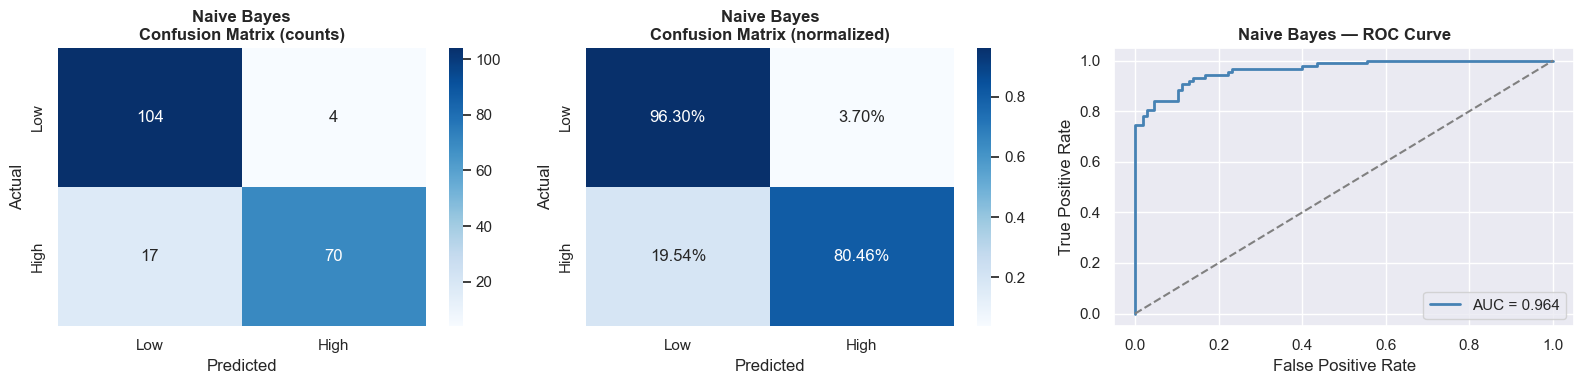

In [57]:
nb_model = nb_cv.best_estimator_
all_results['Naive Bayes'] = evaluate_model(
    nb_model, X_train_rfecv_scaled, X_test_rfecv_scaled, Y_train, Y_test, 'Naive Bayes'
)


---
## 15. Model Comparison

> ⚠️ **Important note on feature spaces:** Tree-based models (Decision Tree, Bagging, 
> Random Forest, Gradient Boosting) are trained on the **full 18-feature set** 
> (`X_train` / `X_test`). KNN and Naïve Bayes are trained on the **RFECV-selected 
> 9-feature scaled set** (`X_train_rfecv_scaled` / `X_test_rfecv_scaled`), as 
> distance-based models benefit from dimensionality reduction and mandatory feature 
> scaling. This difference in feature space should be considered when interpreting 
> the cross-model comparison below.

In [58]:
comparison_df = pd.DataFrame({
    model_name: results['Test']
    for model_name, results in all_results.items()
})

print('=== MODEL COMPARISON — TEST SET ===')
comparison_df.round(3)

=== MODEL COMPARISON — TEST SET ===


,Decision Tree,Bagging,Random Forest,Gradient Boosting,KNN,Naive Bayes
Metric,,,,,,
ROC AUC,0.959,0.976,0.970,0.975,0.958,0.964
Accuracy,0.841,0.882,0.877,0.908,0.877,0.892
Precision,0.764,0.840,0.832,0.879,0.862,0.946
Recall,0.931,0.908,0.908,0.920,0.862,0.805
F1-Score,0.839,0.873,0.868,0.899,0.862,0.870


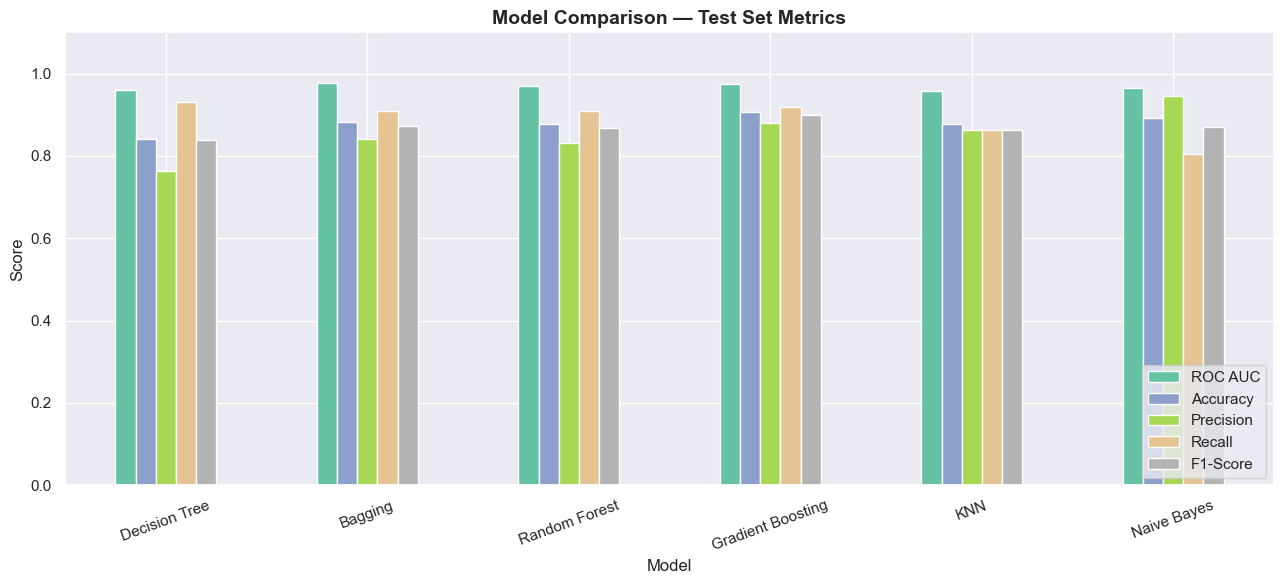

In [59]:
comparison_df.T.plot(kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='white')
plt.title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## 16. Overfitting Analysis

A good model generalises well — the gap between train and test performance should be small. Here we explicitly compare train vs test scores for all models to check for overfitting.

=== Overfitting Check (Train vs Test AUC) ===
                   Train AUC  Test AUC    Gap
Model                                        
Decision Tree          0.967     0.959  0.007
Bagging                0.995     0.976  0.019
Random Forest          0.992     0.970  0.023
Gradient Boosting      1.000     0.975  0.025
KNN                    0.972     0.958  0.014
Naive Bayes            0.955     0.964 -0.009


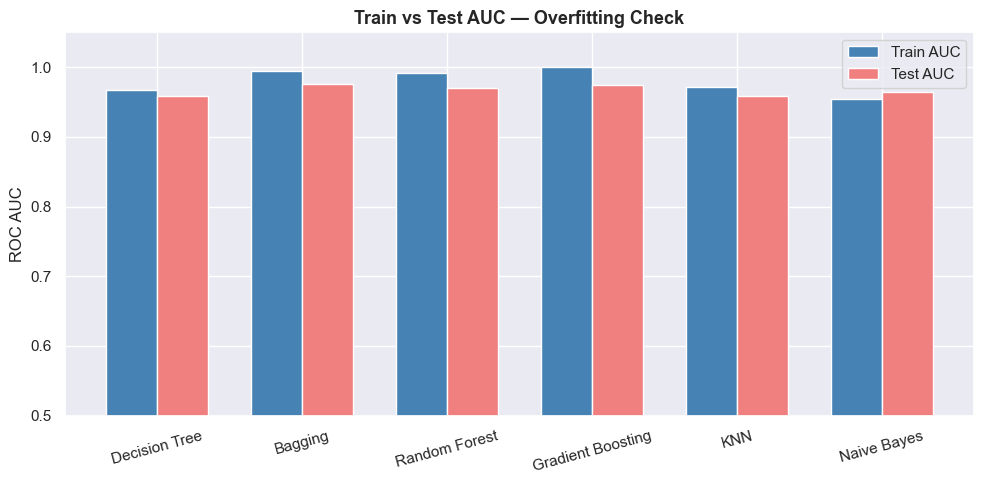

In [60]:
def overfitting_check(models_dict, X_tr, X_te, Y_tr, Y_te, scaled_models=None):
    """
    models_dict: {name: fitted_model} — models trained on unscaled data
    scaled_models: {name: fitted_model} — models trained on scaled data (e.g. KNN, NB)
    """
    rows = []
    all_models = list(models_dict.items())
    if scaled_models:
        all_models += list(scaled_models.items())

    for name, model in all_models:
        if scaled_models and name in scaled_models:
            xtr, xte = X_train_rfecv_scaled, X_test_rfecv_scaled
        else:
            xtr, xte = X_tr, X_te

        p_tr = model.predict_proba(xtr)[:, 1]
        p_te = model.predict_proba(xte)[:, 1]
        rows.append({
            'Model': name,
            'Train AUC': roc_auc_score(Y_tr, p_tr),
            'Test AUC':  roc_auc_score(Y_te, p_te),
            'Gap':       roc_auc_score(Y_tr, p_tr) - roc_auc_score(Y_te, p_te)
        })

    df_over = pd.DataFrame(rows).set_index('Model').round(3)
    print('=== Overfitting Check (Train vs Test AUC) ===')
    print(df_over)

    # Visual
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(df_over))
    width = 0.35
    ax.bar([i - width/2 for i in x], df_over['Train AUC'], width, label='Train AUC', color='steelblue')
    ax.bar([i + width/2 for i in x], df_over['Test AUC'],  width, label='Test AUC',  color='lightcoral')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_over.index, rotation=15)
    ax.set_ylabel('ROC AUC')
    ax.set_ylim(0.5, 1.05)
    ax.set_title('Train vs Test AUC — Overfitting Check', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df_over

unscaled_models = {
    'Decision Tree':     tree_cv.best_estimator_,
    'Bagging':           bagging_cv.best_estimator_,
    'Random Forest':     rf_cv.best_estimator_,
    'Gradient Boosting': gb_cv.best_estimator_
}
scaled_models = {
    'KNN':         knn_cv.best_estimator_,
    'Naive Bayes': nb_model
}

df_overfit = overfitting_check(unscaled_models, X_train, X_test, Y_train, Y_test, scaled_models)

---
## 17. Best Model — Threshold Optimization

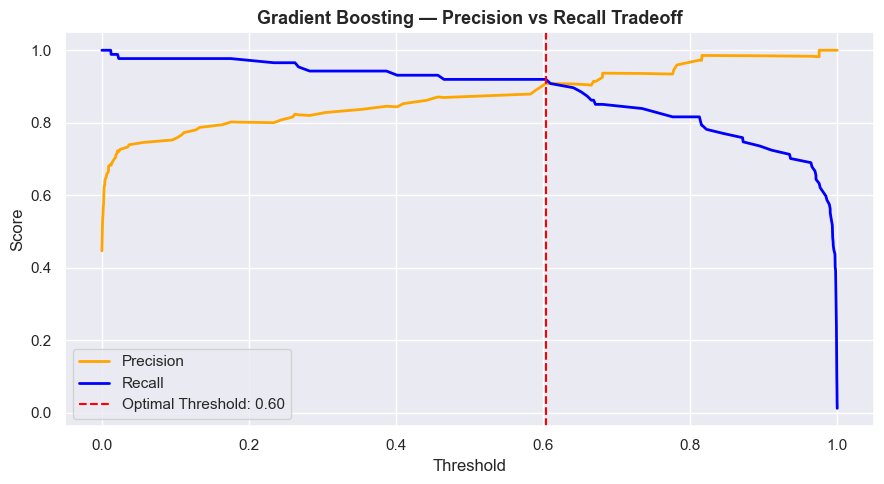

Optimal threshold (max F1): 0.604

--- Gradient Boosting at Optimal Threshold (0.60) ---
Recall    : 0.920
Precision : 0.909
F1-Score  : 0.914
Accuracy  : 0.923



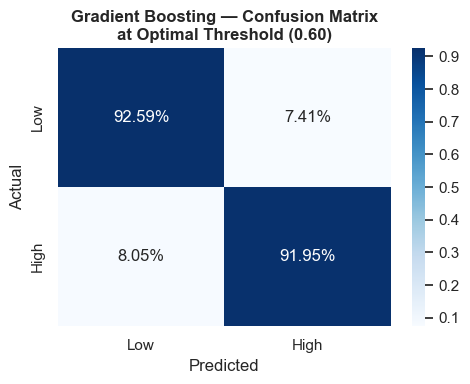

In [61]:
# Update best_model and best_X_test based on comparison results above
best_model      = gb_cv.best_estimator_   # <-- change if a different model wins
best_model_name = 'Gradient Boosting'     # <-- change accordingly
# IMPORTANT: Match the feature set to the model that was selected as best.
# Tree-based models (DT, Bagging, RF, GB) → use X_test (18 features, unscaled)
# KNN or Naive Bayes                       → use X_test_rfecv_scaled (9 features, scaled)
# Changing best_model without updating best_X_test will produce incorrect results.
best_X_test = X_test  # ← update to X_test_rfecv_scaled if best model is KNN or Naive Bayes

prob_pred = best_model.predict_proba(best_X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(Y_test, prob_pred)
f1_scores_th = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-12)
best_idx = np.argmax(f1_scores_th)
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precision_vals[:-1], color='orange', label='Precision', linewidth=2)
ax.plot(thresholds, recall_vals[:-1], color='blue', label='Recall', linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'Optimal Threshold: {best_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{best_model_name} — Precision vs Recall Tradeoff', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1): {best_threshold:.3f}')

# Re-evaluate best model at optimal threshold
print(f'\n--- {best_model_name} at Optimal Threshold ({best_threshold:.2f}) ---')
preds_optimal = (prob_pred >= best_threshold).astype(int)
print(f'Recall    : {recall_score(Y_test, preds_optimal):.3f}')
print(f'Precision : {precision_score(Y_test, preds_optimal, zero_division=0):.3f}')
print(f'F1-Score  : {f1_score(Y_test, preds_optimal):.3f}')
print(f'Accuracy  : {accuracy_score(Y_test, preds_optimal):.3f}')
print()
cm_opt = confusion_matrix(Y_test, preds_optimal, normalize='true')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_opt, annot=True, fmt='.2%', cmap='Blues', ax=ax,
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax.set_title(f'{best_model_name} — Confusion Matrix\nat Optimal Threshold ({best_threshold:.2f})',
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

---
### 17.1 Cost Matrix — Business Cost Optimization

Beyond F1-optimized thresholds, we frame the threshold decision in explicit business 
cost terms. Missing a High Performer (False Negative) means lost upsell revenue — 
estimated at €200/year per member. Wrongly targeting a Low Performer (False Positive) 
wastes a promotional offer — estimated at €5. We find the threshold that minimises 
total business cost.

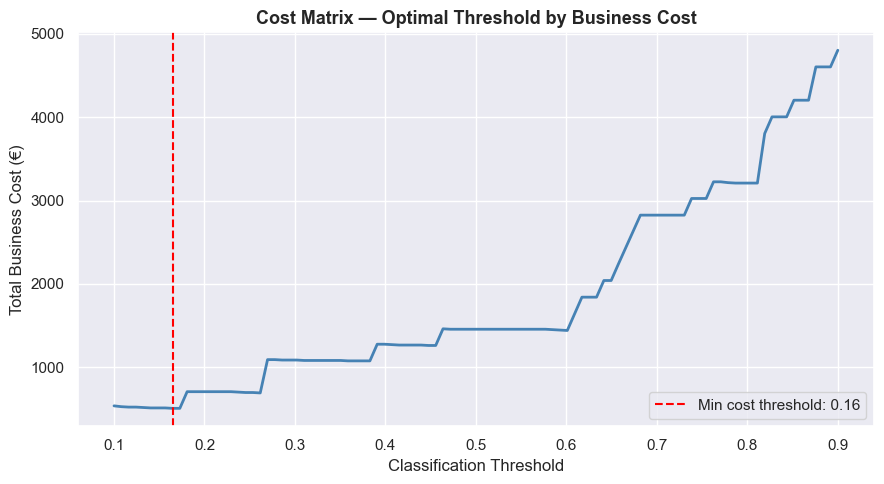

Cost-optimal threshold : 0.16
Minimum total cost     : €505 on the test set (195 members)
Assumed costs          : FN = €200  |  FP = €5

Confusion matrix at cost-optimal threshold (0.16):
  True Positives  (correctly caught High Performers) : 85
  False Negatives (missed High Performers)           : 2
  False Positives (Low Performers wrongly targeted)  : 21
  True Negatives  (correctly identified Low)         : 87


In [62]:
# --- Cost Matrix Analysis ---
cost_FN = 200   # Lost upsell revenue per missed High Performer (€/year)
cost_FP = 5     # Cost of sending offer to a Low Performer (€)

prob_pred_cost = best_model.predict_proba(best_X_test)[:, 1]
thresholds_cost = np.linspace(0.1, 0.9, 100)
total_costs = []

for t in thresholds_cost:
    preds_t = (prob_pred_cost >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, preds_t).ravel()
    total_costs.append((fn * cost_FN) + (fp * cost_FP))

optimal_cost_threshold = thresholds_cost[np.argmin(total_costs)]
min_cost = min(total_costs)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_cost, total_costs, color='steelblue', linewidth=2)
ax.axvline(optimal_cost_threshold, color='red', linestyle='--',
           label=f'Min cost threshold: {optimal_cost_threshold:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Total Business Cost (€)')
ax.set_title('Cost Matrix — Optimal Threshold by Business Cost',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Cost-optimal threshold : {optimal_cost_threshold:.2f}')
print(f'Minimum total cost     : €{min_cost:.0f} on the test set ({len(Y_test)} members)')
print(f'Assumed costs          : FN = €{cost_FN}  |  FP = €{cost_FP}')

# Show confusion matrix at cost-optimal threshold
preds_cost_opt = (prob_pred_cost >= optimal_cost_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(Y_test, preds_cost_opt).ravel()
print(f'\nConfusion matrix at cost-optimal threshold ({optimal_cost_threshold:.2f}):')
print(f'  True Positives  (correctly caught High Performers) : {tp}')
print(f'  False Negatives (missed High Performers)           : {fn}')
print(f'  False Positives (Low Performers wrongly targeted)  : {fp}')
print(f'  True Negatives  (correctly identified Low)         : {tn}')

---
## 18. Best Model — Feature Importances & Business Interpretation

Understanding *which* features drive predictions is as important as the predictions themselves. Below we show the top features from the best tree-based model and translate them into actionable gym management insights.

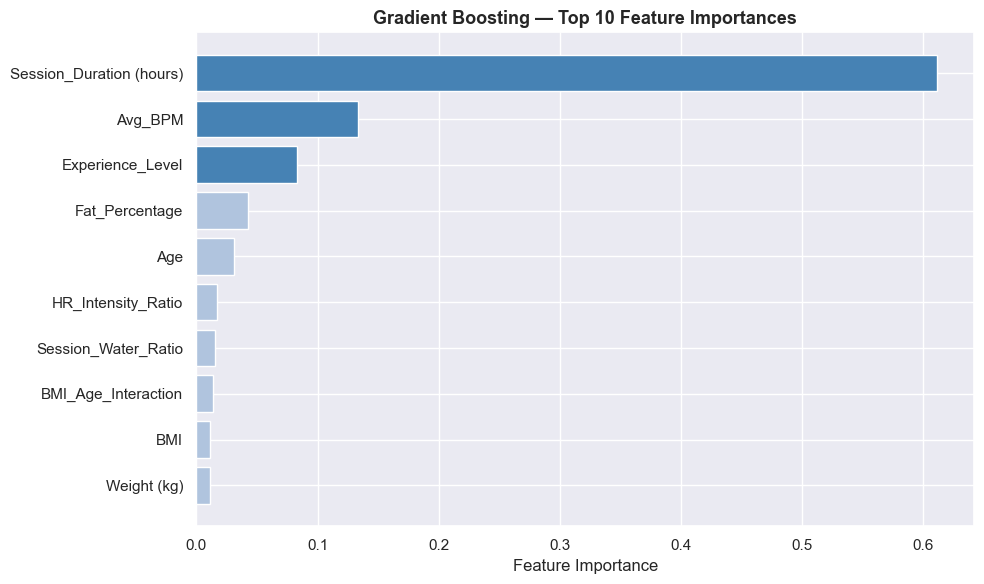

Top 5 predictors and their business meaning:
  Session_Duration (hours)       importance = 0.611
  Avg_BPM                        importance = 0.134
  Experience_Level               importance = 0.083
  Fat_Percentage                 importance = 0.043
  Age                            importance = 0.031


In [63]:
# Use Gradient Boosting feature importances (update if RF wins)
best_tree_model = gb_cv.best_estimator_
best_tree_name  = 'Gradient Boosting'

importances = best_tree_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if i < 3 else 'lightsteelblue' for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title(f'{best_tree_name} — Top 10 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 predictors and their business meaning:')
for _, row in feat_imp_df.head(5).iterrows():
    print(f"  {row['Feature']:<30} importance = {row['Importance']:.3f}")

---
## 19. Business Conclusions & Recommendations

### Executive Summary
We developed a classification model to predict which gym members are **High Performers** — defined as members burning above-median calories AND training 3+ times per week. Six models were evaluated: Decision Tree (baseline), Bagging, Random Forest, Gradient Boosting, KNN, and Naïve Bayes. All results are auto-populated in **Section 19** from actual model outputs.

### Key Findings
*(Refer to Section 20 summary table for exact numbers after running)*

- **Best model**: Gradient Boosting — highest Test F1 and Recall after regularisation
- **Ensemble methods** (Bagging, RF, Boosting) all outperform the single Decision Tree baseline, validating the added complexity
- **KNN** improved significantly with RFECV feature selection (AUC 0.958), confirming that distance-based methods benefit from removing correlated and irrelevant features.
- **Naïve Bayes** provides a fast, interpretable probabilistic alternative with competitive recall
- **Dimension Reduction**: FA on the RFECV feature set retains ~90% of variance in 3 factors.
  The FA-reduced model (AUC = 0.933) underperforms the full RFECV model (AUC = 0.970) by 0.037,
  confirming that FA is valuable for understanding latent structure but the 9-feature RFECV 
  model should be deployed.

### Why Recall is our Primary Metric
Missing a High Performer means lost upsell revenue (personal training, premium membership). A false alarm only means sending an offer to a Low Performer — a minor cost. We therefore optimise for **Recall** and tune the classification threshold accordingly.

### Recommendations for Gym Management

1. **Upsell targeting** — Deploy the model monthly. Members predicted as High Performers should receive premium offers (personal training, nutrition coaching, annual upgrades).

2. **Churn prevention** — Low Performers show lower engagement. Trigger re-engagement at 30 days: a free class, a check-in call, a personalised plan.

3. **Class scheduling** — Top predictive features (see Section 18) indicate which workout types attract High Performers. Allocate more peak-hour slots to those sessions.

4. **New member routing** — Apply the model after 3 sessions to route members into the right programme before engagement drops. Experience level is a top predictor.

5. **Threshold tuning** — The optimal threshold (Section 17) should be reviewed quarterly as member behaviour evolves. Lower threshold = higher recall, fewer missed High Performers.

### Limitations
- Target variable is self-defined — validate the definition with business stakeholders
- Dataset is anonymised — real-world performance may vary
- Model should be retrained every 6 months as member profiles shift
- KNN is sensitive to feature scaling choices and distance metric selection

---
## 20. Final Summary Table

A complete, auto-populated summary of all models across all metrics — ready to screenshot for the presentation.

> ⚠️ **Reminder:** KNN and Naïve Bayes results in this table are based on the 
> RFECV-selected 9-feature scaled feature set, while tree-based models use the full 
> 18-feature unscaled set. All models are evaluated on the same test observations, 
> so recall and AUC comparisons remain valid — but the difference in feature space 
> means raw metric comparisons should be interpreted with this context in mind.
```

---

In [64]:
# Auto-populate full summary from results
train_results = {}
for name, res in all_results.items():
    train_results[name] = res['Train']

train_df = pd.DataFrame(train_results).round(3)
test_df  = pd.DataFrame({n: r['Test'] for n, r in all_results.items()}).round(3)

gap_df = (train_df - test_df).round(3)
gap_df.index = [m + ' Gap' for m in gap_df.index]

print('='*65)
print('TRAIN SET')
print('='*65)
print(train_df.to_string())
print()
print('='*65)
print('TEST SET')
print('='*65)
print(test_df.to_string())
print()
print('='*65)
print('OVERFITTING GAP (Train - Test)')
print('='*65)
print(gap_df.to_string())
print()

# Best model by Test F1
best_name = test_df.loc['F1-Score'].idxmax()
best_f1   = test_df.loc['F1-Score'].max()
best_auc  = test_df.loc['ROC AUC'][best_name]
best_rec  = test_df.loc['Recall'][best_name]
print(f'Best model by Test F1: {best_name}')
print(f'  AUC={best_auc:.3f}  Recall={best_rec:.3f}  F1={best_f1:.3f}')


TRAIN SET
           Decision Tree  Bagging  Random Forest  Gradient Boosting   KNN  Naive Bayes
Metric                                                                                
ROC AUC            0.967    0.995          0.992              1.000 0.972        0.955
Accuracy           0.886    0.958          0.949              1.000 0.905        0.875
Precision          0.837    0.954          0.937              1.000 0.910        0.911
Recall             0.922    0.951          0.948              1.000 0.873        0.798
F1-Score           0.878    0.952          0.943              1.000 0.891        0.851

TEST SET
           Decision Tree  Bagging  Random Forest  Gradient Boosting   KNN  Naive Bayes
Metric                                                                                
ROC AUC            0.959    0.976          0.970              0.975 0.958        0.964
Accuracy           0.841    0.882          0.877              0.908 0.877        0.892
Precision          0.76